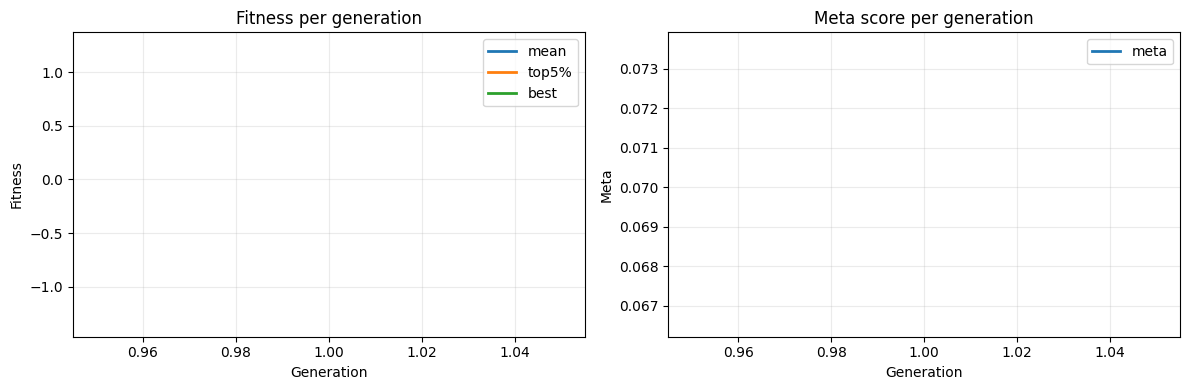

[GEN 0001] mean=-1.338 | top5%=0.410 | best=1.242 | fN=672 fI=584 | meta=0.070 | total_b=194.627


In [ ]:
# ============================================================
# swEM on Taichi GPU + Numpy GA
#   - Parallel env+model in Taichi
#   - GA loop in Numpy
#   - Sharpy meta-fitness + EMA-only looping penalty (this change)
#   - Paired A/B 4-phase episodes (random boundaries)
#   - Inline plots (fitness + meta)
#   - Print AFTER plot; includes total b per generation
# ============================================================

import os, math, numpy as np
from dataclasses import dataclass
from typing import Optional
import taichi as ti
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# Prefer CUDA; fallback to CPU
try:
    ti.init(arch=ti.cuda)
except Exception:
    ti.init(arch=ti.cpu)

# ===================
# Hyperparameters
# ===================
HYPERPARAMS = dict(
    # World / timing
    width=1280,
    height=800,
    dt=1/30.0,
    speed_px_s=55.0,

    # Sensors
    n_rays=3,               # input = n_rays + 1 (reward-event)
    fov_deg=90.0,
    ray_length=60.0,

    # Resources
    food_radius=3.5,
    food_reward=+1.0,
    food_max=1200,

    # Agent body
    agent_radius=5.0,

    # Penalties (only EMA looping penalty is used in fitness)
    consumption_speed_coeff=0.0,
    ema_coeff=0.98,
    looping_penalty=1.5,    # << start with penalty = 4 (requested)
                             # (no other penalties are applied to fitness)

    # Reservoir
    res_N=7,
    res_T=5,
    res_dt=0.2,
    res_abs_max=10.0,
    res_lambda_write=0.15,

    # Conv
    conv_radius=1,          # conv_L = 2*radius+1
    conv_w_init_sigma=0.5,

    # Small-world
    sw_K=2,
    sw_A_init_sigma=0.5,
    sw_b_init_sigma=0.03,
    sw_rewire_mut_prob=0.0005,
    sw_weight_mut_sigma=0.02,

    # Memory / per-neuron
    k_init_sigma=0.15,
    km_init_sigma=0.2,
    am_init_sigma=0.03,
    bs_init_sigma=0.03,

    # Sparse enc/dec
    mod_every=1,
    enc_clip=3.0,
    dec_gain_steer=1.0,
    dec_gain_speed=2.0,

    # Init priors (for first gen; GA overwrites later)
    e_init_sigma=0.8,
    be_init_sigma=0.03,
    r_init_sigma=0.8,
    bd_init_sigma=0.03,
    s0_init_sigma=0.8,
    m0_init_sigma=0.8,

    # GA
    population_size=200,
    generations=300,
    episodes_per_generation=2,   # each episode_pair = A + B
    tournament_k=4,
    elitism=40,
    crossover_prob=0.05,
    mutation_prob=0.2,
    mutation_sigma_base=0.04,
    mutation_t_df=2.0,

    # Bank
    bank_max=256,
    bank_add_every=1,
    immigrants_per_gen=4,

    # Meta / reward input
    meta_learning_enabled=True,
    flip_enabled=True,
    reward_burst_len=4,

    # Resource fairness
    periodic_reset_steps=1,

    # Output
    out_dir="out",
    save_top_k=6,

    # Meta-fitness exponent
    meta_fitness_exp=0.5
)

# ===================
# Config dataclass
# ===================
@dataclass
class Cfg:
    # World / timing
    width: int
    height: int
    dt: float
    speed_px_s: float

    # Sensors
    n_rays: int
    fov_deg: float
    ray_length: float

    # Resources
    food_radius: float
    food_reward: float
    food_max: int

    # Agent body
    agent_radius: float

    # Penalties
    consumption_speed_coeff: float
    ema_coeff: float
    looping_penalty: float

    # Reservoir
    res_N: int
    res_T: int
    res_dt: float
    res_abs_max: float
    res_lambda_write: float

    # Conv
    conv_radius: int
    conv_w_init_sigma: float

    # Small-world
    sw_K: int
    sw_A_init_sigma: float
    sw_b_init_sigma: float
    sw_rewire_mut_prob: float
    sw_weight_mut_sigma: float

    # Learnable per-neuron
    k_init_sigma: float
    km_init_sigma: float
    am_init_sigma: float
    bs_init_sigma: float

    # Sparse enc/dec
    mod_every: int
    enc_clip: float
    dec_gain_steer: float
    dec_gain_speed: float

    # Init priors
    e_init_sigma: float
    be_init_sigma: float
    r_init_sigma: float
    bd_init_sigma: float
    s0_init_sigma: float
    m0_init_sigma: float

    # GA
    population_size: int
    generations: int
    episodes_per_generation: int
    tournament_k: int
    elitism: int
    crossover_prob: float
    mutation_prob: float
    mutation_sigma_base: float
    mutation_t_df: float

    # Bank
    bank_max: int
    bank_add_every: int
    immigrants_per_gen: int

    # Meta / reward input
    meta_learning_enabled: bool
    flip_enabled: bool
    reward_burst_len: int

    # Resets
    periodic_reset_steps: int

    # Output
    out_dir: str
    save_top_k: int

    # Meta fitness exponent
    meta_fitness_exp: float

    # Derived
    input_dim: int = 0
    output_dim: int = 2
    sel_idx: Optional[np.ndarray] = None
    N_sel: int = 0
    conv_L: int = 0
    conv_offsets: Optional[np.ndarray] = None
    steps_per_episode: int = 2000  # fixed here for simplicity

    def __post_init__(self):
        os.makedirs(self.out_dir, exist_ok=True)
        self.input_dim = self.n_rays + 1
        assert self.output_dim == 2
        assert self.mod_every >= 1
        self.sel_idx = np.arange(0, self.res_N, self.mod_every, dtype=np.int32)
        self.N_sel = int(self.sel_idx.size)
        assert self.N_sel >= 1
        self.conv_L = 2 * self.conv_radius + 1
        self.conv_offsets = np.arange(-self.conv_radius, self.conv_radius + 1, dtype=np.int32)
        assert self.sw_K >= 1
        assert self.periodic_reset_steps >= 1
        assert self.reward_burst_len >= 1

def build_cfg_from_hparams(hparams: dict) -> Cfg:
    cfg = Cfg(**hparams)
    return cfg

cfg = build_cfg_from_hparams(HYPERPARAMS)

# ============================================================
# Taichi data-oriented simulator
# ============================================================
@ti.data_oriented
class TaichiEpisodeSim:
    def __init__(self, cfg: Cfg):
        self.cfg = cfg

        # ---- Aliases / dims
        self.A = cfg.population_size
        self.N = cfg.res_N
        self.Ksw = cfg.sw_K
        self.L = cfg.conv_L
        self.I = cfg.input_dim
        self.O = 2
        self.N_sel = cfg.N_sel
        self.n_rays = cfg.n_rays
        self.food_max = cfg.food_max
        self.steps = cfg.steps_per_episode

        # ---- Scalars
        self.W = float(cfg.width)
        self.H = float(cfg.height)
        self.halfW = self.W / 2.0
        self.halfH = self.H / 2.0

        # ---- Fields (state)
        self.a_xy   = ti.Vector.field(2, dtype=ti.f32, shape=self.A)
        self.a_dir  = ti.field(dtype=ti.f32, shape=self.A)
        self.a_speed= ti.field(dtype=ti.f32, shape=self.A)

        self.s      = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self.m      = ti.field(dtype=ti.f32, shape=(self.A, self.N))

        self.reward_evt = ti.field(dtype=ti.f32, shape=self.A)
        self.reward_cnt = ti.field(dtype=ti.i32,  shape=self.A)

        self.pos_inc    = ti.field(dtype=ti.f32, shape=self.A)
        self.neg_inc    = ti.field(dtype=ti.f32, shape=self.A)

        self.food_xy    = ti.Vector.field(2, dtype=ti.f32, shape=self.food_max)
        self.food_active= ti.field(dtype=ti.i32, shape=self.food_max)

        # ---- Episode schedule (max 4 segments)
        self.seg_boundaries = ti.field(dtype=ti.i32, shape=4)
        self.seg_signs      = ti.field(dtype=ti.f32, shape=4)
        self.seg_count      = ti.field(dtype=ti.i32, shape=())
        self.domain_sign    = ti.field(dtype=ti.f32, shape=())

        # ---- Constant / helper arrays
        self.sel_idx = ti.field(dtype=ti.i32, shape=self.N_sel)
        self.sel_idx.from_numpy(cfg.sel_idx.astype(np.int32))

        self.conv_offsets = ti.field(dtype=ti.i32, shape=self.L)
        self.conv_offsets.from_numpy(cfg.conv_offsets.astype(np.int32))

        # ---- Model parameters (per agent)
        self.conv_w = ti.field(dtype=ti.f32, shape=(self.A, self.L))
        self.k      = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self.k_m    = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self.a_m    = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self.b_s    = ti.field(dtype=ti.f32, shape=(self.A, self.N))

        self.F_idx  = ti.field(dtype=ti.i32, shape=(self.A, self.Ksw))
        self.T_idx  = ti.field(dtype=ti.i32, shape=(self.A, self.Ksw))
        self.A_mat  = ti.field(dtype=ti.f32, shape=(self.A, self.Ksw, self.Ksw))
        self.sw_b   = ti.field(dtype=ti.f32, shape=(self.A, self.Ksw))

        self.E      = ti.field(dtype=ti.f32, shape=(self.A, self.N_sel, self.I))
        self.bE     = ti.field(dtype=ti.f32, shape=(self.A, self.N_sel))
        self.R      = ti.field(dtype=ti.f32, shape=(self.A, 2, self.N_sel))
        self.bD     = ti.field(dtype=ti.f32, shape=(self.A, 2))

        # ---- Temp buffers
        self._tmp_sw = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self._tmp_conv = ti.field(dtype=ti.f32, shape=(self.A, self.N))

        # ---- Looping penalty state (EMA of steering)
        self.ema_steer = ti.field(dtype=ti.f32, shape=self.A)

    def load_params(
        self,
        conv_w, k, k_m, a_m, b_s,
        F_idx, T_idx, A_mat, sw_b,
        E, bE, R, bD,
        s0, m0
    ):
        assert conv_w.shape == (self.A, self.L)
        assert k.shape == k_m.shape == a_m.shape == b_s.shape == (self.A, self.N)
        assert F_idx.shape == T_idx.shape == (self.A, self.Ksw)
        assert A_mat.shape == (self.A, self.Ksw, self.Ksw)
        assert sw_b.shape == (self.A, self.Ksw)
        assert E.shape == (self.A, self.N_sel, self.I)
        assert bE.shape == (self.A, self.N_sel)
        assert R.shape == (self.A, 2, self.N_sel)
        assert bD.shape == (self.A, 2)
        assert s0.shape == m0.shape == (self.A, self.N)

        self.conv_w.from_numpy(conv_w.astype(np.float32))
        self.k.from_numpy(k.astype(np.float32))
        self.k_m.from_numpy(k_m.astype(np.float32))
        self.a_m.from_numpy(a_m.astype(np.float32))
        self.b_s.from_numpy(b_s.astype(np.float32))

        self.F_idx.from_numpy(F_idx.astype(np.int32))
        self.T_idx.from_numpy(T_idx.astype(np.int32))
        self.A_mat.from_numpy(A_mat.astype(np.float32))
        self.sw_b.from_numpy(sw_b.astype(np.float32))

        self.E.from_numpy(E.astype(np.float32))
        self.bE.from_numpy(bE.astype(np.float32))
        self.R.from_numpy(R.astype(np.float32))
        self.bD.from_numpy(bD.astype(np.float32))

        self.s.from_numpy(s0.astype(np.float32))
        self.m.from_numpy(m0.astype(np.float32))

    def set_segments(self, lengths, signs):
        assert len(lengths) == len(signs) <= 4
        assert sum(int(x) for x in lengths) == self.steps
        self.seg_count[None] = len(lengths)
        cumsum = 0
        for i, (L, sg) in enumerate(zip(lengths, signs)):
            cumsum += int(L)
            self.seg_boundaries[i] = cumsum
            self.seg_signs[i] = float(sg)
        for i in range(len(lengths), 4):
            self.seg_boundaries[i] = self.steps
            self.seg_signs[i] = 0.0
        self.domain_sign[None] = float(signs[0])

    def reset_episode(self):
        self._spawn_agents()
        self._reset_agent_buffers()
        self._reset_food()

    @ti.kernel
    def _spawn_agents(self):
        for a in range(self.A):
            self.a_xy[a] = ti.Vector([ti.random(dtype=ti.f32) * self.W,
                                      ti.random(dtype=ti.f32) * self.H])
            self.a_dir[a] = ti.random(dtype=ti.f32) * 2.0 * ti.math.pi
            self.a_speed[a] = 0.0

    @ti.kernel
    def _reset_agent_buffers(self):
        for a in range(self.A):
            self.reward_evt[a] = 0.0
            self.reward_cnt[a] = 0
            self.pos_inc[a] = 0.0
            self.neg_inc[a] = 0.0
            self.ema_steer[a] = 0.0   # reset EMA each episode

    @ti.kernel
    def _reset_food(self):
        for f in range(self.food_max):
            self.food_xy[f] = ti.Vector([ti.random(dtype=ti.f32) * self.W,
                                         ti.random(dtype=ti.f32) * self.H])
            self.food_active[f] = 1

    @ti.kernel
    def _replenish_food_to_target(self):
        for f in range(self.food_max):
            if self.food_active[f] == 0:
                self.food_active[f] = 1
                self.food_xy[f] = ti.Vector([ti.random(dtype=ti.f32) * self.W,
                                             ti.random(dtype=ti.f32) * self.H])

    @ti.func
    def _delta_torus(self, dx: ti.f32, W: ti.f32, half: ti.f32) -> ti.f32:
        return (dx + half) % W - half

    @ti.func
    def _nearest_food_dist_for_ray(self, a: ti.i32, dir_angle: ti.f32, max_len: ti.f32,
                                   half_beam: ti.f32, use_half_beam: ti.i32,
                                   step_half: ti.f32) -> ti.f32:
        ax = self.a_xy[a][0]
        ay = self.a_xy[a][1]
        best = max_len
        for f in range(self.food_max):
            if self.food_active[f] == 1:
                dx = self._delta_torus(self.food_xy[f][0] - ax, self.W, self.halfW)
                dy = self._delta_torus(self.food_xy[f][1] - ay, self.H, self.halfH)
                dist = ti.sqrt(dx*dx + dy*dy)
                if dist <= max_len:
                    ang = ti.atan2(dy, dx)
                    diff = ti.abs(ti.atan2(ti.sin(ang - dir_angle), ti.cos(ang - dir_angle)))
                    if use_half_beam == 1:
                        if diff < half_beam and dist < best:
                            best = dist
                    else:
                        if diff < step_half and dist < best:
                            best = dist
        return best / max_len

    @ti.kernel
    def _decay_reward_events(self):
        for a in range(self.A):
            if self.reward_cnt[a] > 0:
                self.reward_cnt[a] -= 1
                if self.reward_cnt[a] == 0:
                    self.reward_evt[a] = 0.0

    @ti.kernel
    def _sense_and_encode(self, meta_enabled: ti.i32, enc_clip: ti.f32, lambda_write: ti.f32,
                          fov_rad: ti.f32, step_half: ti.f32, half_beam: ti.f32, use_half_beam: ti.i32,
                          ray_len: ti.f32):
        for a in range(self.A):
            base = self.a_dir[a]
            for sel in range(self.N_sel):
                acc = 0.0
                # rays
                for r in range(self.n_rays):
                    rel = ti.cast(0.0, ti.f32)
                    if self.n_rays == 1:
                        rel = 0.0
                    else:
                        rel = -0.5 * fov_rad + (fov_rad * ti.cast(r, ti.f32)) / ti.cast(self.n_rays - 1, ti.f32)
                    ang = base + rel
                    d_norm = self._nearest_food_dist_for_ray(a, ang, ray_len,
                                                             half_beam, use_half_beam, step_half)
                    acc += self.E[a, sel, r] * d_norm
                # reward-event
                rv = self.reward_evt[a] if meta_enabled == 1 else 0.0
                acc += self.E[a, sel, self.n_rays] * rv
                acc += self.bE[a, sel]
                # clip
                if enc_clip > 0:
                    if acc > enc_clip: acc = enc_clip
                    if acc < -enc_clip: acc = -enc_clip
                idx = self.sel_idx[sel]
                self.s[a, idx] += lambda_write * acc

    @ti.kernel
    def _swem_integrate(self, dt: ti.f32, iters: ti.i32, abs_max: ti.f32):
        for _ in range(iters):
            for a in range(self.A):
                for n in range(self.N):
                    self._tmp_sw[a, n] = 0.0
            # small-world scatter
            for a in range(self.A):
                for j in range(self.Ksw):
                    acc = 0.0
                    for k in range(self.Ksw):
                        acc += self.A_mat[a, j, k] * (self.s[a, self.F_idx[a, k]])
                    z = acc + self.sw_b[a, j]
                    t_idx = self.T_idx[a, j]
                    ti.atomic_add(self._tmp_sw[a, t_idx], z)
            # conv
            for a in range(self.A):
                for n in range(self.N):
                    acc = 0.0
                    for l in range(self.L):
                        off = self.conv_offsets[l]
                        idx = (n + off + self.N) % self.N
                        acc += self.conv_w[a, l] * self.s[a, idx]
                    self._tmp_conv[a, n] = acc
            # integrate
            for a in range(self.A):
                for n in range(self.N):
                    pre = self._tmp_conv[a, n] + self._tmp_sw[a, n] + self.b_s[a, n]
                    ds = ti.tanh(pre) + self.k[a, n] * self.s[a, n] + self.k_m[a, n] * (self.m[a, n] - self.s[a, n])
                    dm = self.a_m[a, n] * (self.s[a, n] - self.m[a, n])
                    s_new = self.s[a, n] + dt * ds
                    m_new = self.m[a, n] + dt * dm
                    if s_new > abs_max: s_new = abs_max
                    if s_new < -abs_max: s_new = -abs_max
                    if m_new > abs_max: m_new = abs_max
                    if m_new < -abs_max: m_new = -abs_max
                    self.s[a, n] = s_new
                    self.m[a, n] = m_new

    @ti.kernel
    def _decode_and_move(self, gain_steer: ti.f32, gain_speed: ti.f32, dt: ti.f32, speed_px_s: ti.f32,
                         ema_alpha: ti.f32):
        for a in range(self.A):
            y0 = 0.0
            y1 = 0.0
            for sel in range(self.N_sel):
                idx = self.sel_idx[sel]
                y0 += self.R[a, 0, sel] * self.s[a, idx]
                y1 += self.R[a, 1, sel] * self.s[a, idx]
            y0 += self.bD[a, 0]
            y1 += self.bD[a, 1]

            steer_raw = y0 * gain_steer
            speed_raw = y1 * gain_speed
            if steer_raw > 1.0: steer_raw = 1.0
            if steer_raw < -1.0: steer_raw = -1.0
            speed_cmd = 0.5 + 0.5 * speed_raw
            if speed_cmd < 0.0: speed_cmd = 0.0
            if speed_cmd > 1.0: speed_cmd = 1.0

            # EMA update (looping penalty signal)
            # ema = alpha * ema + (1 - alpha) * steer_raw
            self.ema_steer[a] = ema_alpha * self.ema_steer[a] + (1.0 - ema_alpha) * steer_raw

            new_dir = self.a_dir[a] + steer_raw * (ti.math.pi / 4.0)
            twopi = 2.0 * ti.math.pi
            new_dir = new_dir % twopi
            self.a_dir[a] = new_dir
            self.a_speed[a] = speed_cmd

            dx = speed_cmd * ti.cos(new_dir) * speed_px_s * dt
            dy = speed_cmd * ti.sin(new_dir) * speed_px_s * dt
            x = (self.a_xy[a][0] + dx) % self.W
            y = (self.a_xy[a][1] + dy) % self.H
            self.a_xy[a] = ti.Vector([x, y])

    @ti.kernel
    def _collisions_and_events(self, agent_r: ti.f32, food_r: ti.f32, reward_burst_len: ti.i32):
        Rsum = agent_r + food_r
        R2 = Rsum * Rsum
        for f in range(self.food_max):
            if self.food_active[f] == 1:
                eaten = 0
                eater = -1
                for a in range(self.A):
                    dx = (self.food_xy[f][0] - self.a_xy[a][0] + self.W * 0.5) % self.W - self.W * 0.5
                    dy = (self.food_xy[f][1] - self.a_xy[a][1] + self.H * 0.5) % self.H - self.H * 0.5
                    d2 = dx*dx + dy*dy
                    if d2 < R2:
                        eaten = 1
                        eater = a
                if eaten == 1:
                    self.food_active[f] = 0
                    if self.domain_sign[None] > 0.0:
                        ti.atomic_add(self.pos_inc[eater], 1.0)
                    else:
                        ti.atomic_add(self.neg_inc[eater], 1.0)
                    val = 1.0 if self.domain_sign[None] > 0.0 else -1.0
                    self.reward_evt[eater] = val
                    self.reward_cnt[eater] = reward_burst_len

    @ti.kernel
    def _maybe_segment_boundary(self, step: ti.i32):
        cnt = self.seg_count[None]
        found = 0
        new_sign = self.domain_sign[None]
        for i in range(cnt):
            if step == self.seg_boundaries[i]:
                found = 1
                new_sign = self.seg_signs[i]
        if found == 1:
            self.domain_sign[None] = new_sign
            for f in range(self.food_max):
                self.food_xy[f] = ti.Vector([ti.random(dtype=ti.f32) * self.W,
                                             ti.random(dtype=ti.f32) * self.H])
                self.food_active[f] = 1

    def run_episode(self):
        fov_rad = math.radians(self.cfg.fov_deg)
        use_half_beam = 1 if self.n_rays == 1 else 0
        half_beam = fov_rad * 0.5 if self.n_rays == 1 else 0.0
        step_half = (fov_rad / max(1, self.n_rays - 1)) * 0.5 if self.n_rays > 1 else 0.0
        ema_alpha = float(self.cfg.ema_coeff)

        for step in range(self.steps):
            self._decay_reward_events()
            self._sense_and_encode(
                1 if self.cfg.meta_learning_enabled else 0,
                float(self.cfg.enc_clip),
                float(self.cfg.res_lambda_write),
                float(fov_rad),
                float(step_half),
                float(half_beam),
                int(use_half_beam),
                float(self.cfg.ray_length)
            )
            self._swem_integrate(
                float(self.cfg.res_dt),
                int(self.cfg.res_T),
                float(self.cfg.res_abs_max)
            )
            self._decode_and_move(
                float(self.cfg.dec_gain_steer),
                float(self.cfg.dec_gain_speed),
                float(self.cfg.dt),
                float(self.cfg.speed_px_s),
                float(ema_alpha)
            )
            self._collisions_and_events(
                float(self.cfg.agent_radius),
                float(self.cfg.food_radius),
                int(self.cfg.reward_burst_len)
            )
            if self.cfg.periodic_reset_steps > 0:
                if (step % self.cfg.periodic_reset_steps) == 0 and step > 0:
                    self._replenish_food_to_target()
            self._maybe_segment_boundary(step + 1)

        return (
            self.pos_inc.to_numpy(),
            self.neg_inc.to_numpy(),
            self.s.to_numpy(),
            self.m.to_numpy()
        )

# ============================================================
# GA helpers (numpy)
# ============================================================
def top_percentile_mean(values: np.ndarray, pct: float = 0.05) -> float:
    n = values.size
    if n == 0 or not np.isfinite(values).any():
        return float("nan")
    k = max(1, int(np.ceil(pct * n)))
    part = np.partition(values, n - k)
    return float(np.mean(part[n - k:]))

def crossover_two(rng: np.random.Generator, A: np.ndarray, B: np.ndarray, p: float) -> np.ndarray:
    mask = (rng.random(A.shape) < p)
    return np.where(mask, A, B).astype(np.float32)

def student_t_mutate(rng: np.random.Generator, arr: np.ndarray, mut_prob: float, sigma_base: float, t_df: float):
    if mut_prob <= 0.0 or sigma_base <= 0.0:
        return arr
    mask = (rng.random(arr.shape) < mut_prob)
    if mask.any():
        out = arr.copy()
        t_noise = rng.standard_t(df=t_df, size=int(mask.sum())).astype(np.float32)
        mag = np.abs(out[mask]) + 1e-3
        out[mask] += (sigma_base * mag) * t_noise
        return out
    return arr

def mutate_sw_indices(rng: np.random.Generator, idx: np.ndarray, prob_rewire: float, N: int) -> np.ndarray:
    if prob_rewire <= 0.0:
        return idx
    mask = (rng.random(idx.shape) < prob_rewire)
    if mask.any():
        out = idx.copy()
        out[mask] = rng.integers(0, N, size=int(mask.sum()), dtype=np.int32)
        return out
    return idx

def mutate_sw_weights(rng: np.random.Generator, A_mat: np.ndarray, mut_prob: float, sigma_base: float, t_df: float) -> np.ndarray:
    return student_t_mutate(rng, A_mat, mut_prob, sigma_base, t_df)

# ============================================================
# GA Trainer (uses TaichiEpisodeSim for rollouts)
# ============================================================
class GATrainer:
    def __init__(self, cfg: Cfg):
        self.cfg = cfg
        self.rng = np.random.default_rng()
        self.sim = TaichiEpisodeSim(cfg)
        self._init_population()
        self.bank = []
        self.history = []

    def _init_population(self):
        cfg = self.cfg
        A, N, L, K, I, O, N_sel = cfg.population_size, cfg.res_N, cfg.conv_L, cfg.sw_K, cfg.input_dim, 2, cfg.N_sel

        self.conv_w = self.rng.normal(0.0, cfg.conv_w_init_sigma, size=(A, L)).astype(np.float32)
        self.k      = self.rng.normal(0.0, cfg.k_init_sigma,     size=(A, N)).astype(np.float32)
        self.k_m    = self.rng.normal(0.0, cfg.km_init_sigma,    size=(A, N)).astype(np.float32)
        self.a_m    = self.rng.normal(0.0, cfg.am_init_sigma,    size=(A, N)).astype(np.float32)
        self.b_s    = self.rng.normal(0.0, cfg.bs_init_sigma,    size=(A, N)).astype(np.float32)

        self.E      = self.rng.normal(0.0, cfg.e_init_sigma,     size=(A, N_sel, I)).astype(np.float32)
        self.bE     = self.rng.normal(0.0, cfg.be_init_sigma,    size=(A, N_sel)).astype(np.float32)
        self.R      = self.rng.normal(0.0, cfg.r_init_sigma,     size=(A, O, N_sel)).astype(np.float32)
        self.bD     = self.rng.normal(0.0, cfg.bd_init_sigma,    size=(A, O)).astype(np.float32)

        self.F_idx  = self.rng.integers(0, N, size=(A, K), dtype=np.int32)
        self.T_idx  = self.rng.integers(0, N, size=(A, K), dtype=np.int32)
        self.A_mat  = self.rng.normal(0.0, cfg.sw_A_init_sigma, size=(A, K, K)).astype(np.float32)
        self.sw_b   = self.rng.normal(0.0, cfg.sw_b_init_sigma, size=(A, K)).astype(np.float32)

        self.s      = self.rng.normal(0.0, cfg.s0_init_sigma, size=(A, N)).astype(np.float32)
        self.m      = self.rng.normal(0.0, cfg.m0_init_sigma, size=(A, N)).astype(np.float32)

    # ---------- Bank ----------
    def _snapshot_to_bank(self, fitness: np.ndarray):
        cfg = self.cfg
        best_idx = int(np.argmax(fitness))
        entry = dict(
            conv_w=self.conv_w[best_idx].copy(),
            k=self.k[best_idx].copy(),
            k_m=self.k_m[best_idx].copy(),
            a_m=self.a_m[best_idx].copy(),
            b_s=self.b_s[best_idx].copy(),
            E=self.E[best_idx].copy(),
            bE=self.bE[best_idx].copy(),
            R=self.R[best_idx].copy(),
            bD=self.bD[best_idx].copy(),
            F_idx=self.F_idx[best_idx].copy(),
            T_idx=self.T_idx[best_idx].copy(),
            A_mat=self.A_mat[best_idx].copy(),
            sw_b=self.sw_b[best_idx].copy(),
            s=self.s[best_idx].copy(),
            m=self.m[best_idx].copy(),
            fitness=float(fitness[best_idx]),
        )
        self.bank.append(entry)
        if len(self.bank) > cfg.bank_max:
            self.bank = self.bank[-cfg.bank_max:]

    def _immigrants_from_bank(self, n):
        n = min(n, len(self.bank))
        if n <= 0:
            return None
        ids = self.rng.choice(len(self.bank), size=n, replace=False)
        sel = [self.bank[i] for i in ids]
        def stack(key, dtype=np.float32):
            return np.stack([e[key] for e in sel]).astype(dtype)
        return dict(
            conv_w=stack("conv_w"),
            k=stack("k"),
            k_m=stack("k_m"),
            a_m=stack("a_m"),
            b_s=stack("b_s"),
            E=stack("E"),
            bE=stack("bE"),
            R=stack("R"),
            bD=stack("bD"),
            F_idx=stack("F_idx", np.int32),
            T_idx=stack("T_idx", np.int32),
            A_mat=stack("A_mat"),
            sw_b=stack("sw_b"),
            s=stack("s"),
            m=stack("m"),
        )

    # ---------- Selection ----------
    def tournament_select(self, fitness: np.ndarray, k: int) -> int:
        A = len(fitness)
        idxs = self.rng.integers(0, A, size=k)
        best = idxs[np.argmax(fitness[idxs])]
        return int(best)

    # ---------- Reproduction ----------
    def reproduce(self, fitness: np.ndarray):
        cfg = self.cfg
        A, N, L, K, I, O, N_sel = cfg.population_size, cfg.res_N, cfg.conv_L, cfg.sw_K, cfg.input_dim, 2, cfg.N_sel

        order = np.argsort(-fitness)
        elites_idx = order[:cfg.elitism]

        conv_w_n = np.empty((A, L), np.float32)
        k_n      = np.empty((A, N), np.float32)
        k_m_n    = np.empty((A, N), np.float32)
        a_m_n    = np.empty((A, N), np.float32)
        b_s_n    = np.empty((A, N), np.float32)
        E_n      = np.empty((A, N_sel, I), np.float32)
        bE_n     = np.empty((A, N_sel), np.float32)
        R_n      = np.empty((A, O, N_sel), np.float32)
        bD_n     = np.empty((A, O), np.float32)
        F_idx_n  = np.empty((A, K), np.int32)
        T_idx_n  = np.empty((A, K), np.int32)
        A_mat_n  = np.empty((A, K, K), np.float32)
        sw_b_n   = np.empty((A, K), np.float32)
        s_n      = np.empty((A, N), np.float32)
        m_n      = np.empty((A, N), np.float32)

        # elites
        conv_w_n[:cfg.elitism] = self.conv_w[elites_idx]
        k_n[:cfg.elitism]      = self.k[elites_idx]
        k_m_n[:cfg.elitism]    = self.k_m[elites_idx]
        a_m_n[:cfg.elitism]    = self.a_m[elites_idx]
        b_s_n[:cfg.elitism]    = self.b_s[elites_idx]
        E_n[:cfg.elitism]      = self.E[elites_idx]
        bE_n[:cfg.elitism]     = self.bE[elites_idx]
        R_n[:cfg.elitism]      = self.R[elites_idx]
        bD_n[:cfg.elitism]     = self.bD[elites_idx]
        F_idx_n[:cfg.elitism]  = self.F_idx[elites_idx]
        T_idx_n[:cfg.elitism]  = self.T_idx[elites_idx]
        A_mat_n[:cfg.elitism]  = self.A_mat[elites_idx]
        sw_b_n[:cfg.elitism]   = self.sw_b[elites_idx]
        s_n[:cfg.elitism]      = self.s[elites_idx]
        m_n[:cfg.elitism]      = self.m[elites_idx]

        # children
        for i in range(cfg.elitism, A):
            pa = self.tournament_select(fitness, cfg.tournament_k)
            pb = self.tournament_select(fitness, cfg.tournament_k)

            conv_c = crossover_two(self.rng, self.conv_w[pa], self.conv_w[pb], cfg.crossover_prob)
            k_c    = crossover_two(self.rng, self.k[pa],      self.k[pb],      cfg.crossover_prob)
            k_m_c  = crossover_two(self.rng, self.k_m[pa],    self.k_m[pb],    cfg.crossover_prob)
            a_m_c  = crossover_two(self.rng, self.a_m[pa],    self.a_m[pb],    cfg.crossover_prob)
            b_s_c  = crossover_two(self.rng, self.b_s[pa],    self.b_s[pb],    cfg.crossover_prob)
            E_c    = crossover_two(self.rng, self.E[pa],      self.E[pb],      cfg.crossover_prob)
            bE_c   = crossover_two(self.rng, self.bE[pa],     self.bE[pb],     cfg.crossover_prob)
            R_c    = crossover_two(self.rng, self.R[pa],      self.R[pb],      cfg.crossover_prob)
            bD_c   = crossover_two(self.rng, self.bD[pa],     self.bD[pb],     cfg.crossover_prob)

            conv_c = student_t_mutate(self.rng, conv_c, cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            k_c    = student_t_mutate(self.rng, k_c,    cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            k_m_c  = student_t_mutate(self.rng, k_m_c,  cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            a_m_c  = student_t_mutate(self.rng, a_m_c,  cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            b_s_c  = student_t_mutate(self.rng, b_s_c,  cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            E_c    = student_t_mutate(self.rng, E_c,    cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            bE_c   = student_t_mutate(self.rng, bE_c,   cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            R_c    = student_t_mutate(self.rng, R_c,    cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            bD_c   = student_t_mutate(self.rng, bD_c,   cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)

            F_c   = mutate_sw_indices(self.rng, self.F_idx[pa], cfg.sw_rewire_mut_prob, cfg.res_N)
            T_c   = mutate_sw_indices(self.rng, self.T_idx[pa], cfg.sw_rewire_mut_prob, cfg.res_N)
            A_c   = mutate_sw_weights(self.rng, self.A_mat[pa], cfg.mutation_prob, cfg.sw_weight_mut_sigma, cfg.mutation_t_df)
            swb_c = student_t_mutate(self.rng, self.sw_b[pa],  cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)

            s_c = crossover_two(self.rng, self.s[pa], self.s[pb], cfg.crossover_prob)
            m_c = crossover_two(self.rng, self.m[pa], self.m[pb], cfg.crossover_prob)
            s_c = student_t_mutate(self.rng, s_c, cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            m_c = student_t_mutate(self.rng, m_c, cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)

            conv_w_n[i] = conv_c
            k_n[i]      = k_c
            k_m_n[i]    = k_m_c
            a_m_n[i]    = a_m_c
            b_s_n[i]    = b_s_c
            E_n[i]      = E_c
            bE_n[i]     = bE_c
            R_n[i]      = R_c
            bD_n[i]     = bD_c
            F_idx_n[i]  = F_c.astype(np.int32)
            T_idx_n[i]  = T_c.astype(np.int32)
            A_mat_n[i]  = A_c
            sw_b_n[i]   = swb_c
            s_n[i]      = s_c
            m_n[i]      = m_c

        self.next_conv_w = conv_w_n
        self.next_k      = k_n
        self.next_k_m    = k_m_n
        self.next_a_m    = a_m_n
        self.next_b_s    = b_s_n
        self.next_E      = E_n
        self.next_bE     = bE_n
        self.next_R      = R_n
        self.next_bD     = bD_n
        self.next_F_idx  = F_idx_n
        self.next_T_idx  = T_idx_n
        self.next_A_mat  = A_mat_n
        self.next_sw_b   = sw_b_n
        self.next_s      = s_n
        self.next_m      = m_n

    # ---------- Assemble main eval population ----------
    def assemble_population(self):
        cfg = self.cfg
        A = cfg.population_size
        elite_n = cfg.elitism
        max_imm_allowed = max(0, A - elite_n)
        imm_n = min(cfg.immigrants_per_gen, len(self.bank), max_imm_allowed)
        imms = self._immigrants_from_bank(imm_n) if imm_n > 0 else None
        child_n = A - (imm_n + elite_n)
        assert child_n >= 0

        N, I, O, L, K, N_sel = cfg.res_N, cfg.input_dim, 2, cfg.conv_L, cfg.sw_K, cfg.N_sel
        conv_w = np.empty((A, L), np.float32)
        k      = np.empty((A, N), np.float32)
        k_m    = np.empty((A, N), np.float32)
        a_m    = np.empty((A, N), np.float32)
        b_s    = np.empty((A, N), np.float32)
        E      = np.empty((A, N_sel, I), np.float32)
        bE     = np.empty((A, N_sel), np.float32)
        R      = np.empty((A, O, N_sel), np.float32)
        bD     = np.empty((A, O), np.float32)
        F_idx  = np.empty((A, K), np.int32)
        T_idx  = np.empty((A, K), np.int32)
        A_mat  = np.empty((A, K, K), np.float32)
        sw_b   = np.empty((A, K), np.float32)
        s      = np.empty((A, N), np.float32)
        m      = np.empty((A, N), np.float32)

        ptr = 0
        if imms is not None:
            n = imms["conv_w"].shape[0]
            conv_w[ptr:ptr+n] = imms["conv_w"]
            k[ptr:ptr+n]      = imms["k"]
            k_m[ptr:ptr+n]    = imms["k_m"]
            a_m[ptr:ptr+n]    = imms["a_m"]
            b_s[ptr:ptr+n]    = imms["b_s"]
            E[ptr:ptr+n]      = imms["E"]
            bE[ptr:ptr+n]     = imms["bE"]
            R[ptr:ptr+n]      = imms["R"]
            bD[ptr:ptr+n]     = imms["bD"]
            F_idx[ptr:ptr+n]  = imms["F_idx"]
            T_idx[ptr:ptr+n]  = imms["T_idx"]
            A_mat[ptr:ptr+n]  = imms["A_mat"]
            sw_b[ptr:ptr+n]   = imms["sw_b"]
            s[ptr:ptr+n]      = imms["s"]
            m[ptr:ptr+n]      = imms["m"]
            ptr += n

        n = elite_n
        conv_w[ptr:ptr+n] = self.next_conv_w[:n]
        k[ptr:ptr+n]      = self.next_k[:n]
        k_m[ptr:ptr+n]    = self.next_k_m[:n]
        a_m[ptr:ptr+n]    = self.next_a_m[:n]
        b_s[ptr:ptr+n]    = self.next_b_s[:n]
        E[ptr:ptr+n]      = self.next_E[:n]
        bE[ptr:ptr+n]     = self.next_bE[:n]
        R[ptr:ptr+n]      = self.next_R[:n]
        bD[ptr:ptr+n]     = self.next_bD[:n]
        F_idx[ptr:ptr+n]  = self.next_F_idx[:n]
        T_idx[ptr:ptr+n]  = self.next_T_idx[:n]
        A_mat[ptr:ptr+n]  = self.next_A_mat[:n]
        sw_b[ptr:ptr+n]   = self.next_sw_b[:n]
        s[ptr:ptr+n]      = self.next_s[:n]
        m[ptr:ptr+n]      = self.next_m[:n]
        ptr += n

        n = child_n
        start = elite_n
        end   = elite_n + n
        conv_w[ptr:ptr+n] = self.next_conv_w[start:end]
        k[ptr:ptr+n]      = self.next_k[start:end]
        k_m[ptr:ptr+n]    = self.next_k_m[start:end]
        a_m[ptr:ptr+n]    = self.next_a_m[start:end]
        b_s[ptr:ptr+n]    = self.next_b_s[start:end]
        E[ptr:ptr+n]      = self.next_E[start:end]
        bE[ptr:ptr+n]     = self.next_bE[start:end]
        R[ptr:ptr+n]      = self.next_R[start:end]
        bD[ptr:ptr+n]     = self.next_bD[start:end]
        F_idx[ptr:ptr+n]  = self.next_F_idx[start:end]
        T_idx[ptr:ptr+n]  = self.next_T_idx[start:end]
        A_mat[ptr:ptr+n]  = self.next_A_mat[start:end]
        sw_b[ptr:ptr+n]   = self.next_sw_b[start:end]
        s[ptr:ptr+n]      = self.next_s[start:end]
        m[ptr:ptr+n]      = self.next_m[start:end]
        ptr += n

        assert ptr == A
        return dict(conv_w=conv_w, k=k, k_m=k_m, a_m=a_m, b_s=b_s,
                    E=E, bE=bE, R=R, bD=bD,
                    F_idx=F_idx, T_idx=T_idx, A_mat=A_mat, sw_b=sw_b,
                    s=s, m=m)

    # ---------- Inline plots ----------
    def _plot_inline(self):
        if not self.history:
            return
        gens = [h["gen"] for h in self.history]
        mean = [h["mean"] for h in self.history]
        top5 = [h["top5"] for h in self.history]
        best = [h["best"] for h in self.history]
        meta = [h["meta"] for h in self.history]

        clear_output(wait=True)
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))

        axs[0].plot(gens, mean, label="mean", linewidth=2)
        axs[0].plot(gens, top5, label="top5%", linewidth=2)
        axs[0].plot(gens, best, label="best", linewidth=2)
        axs[0].set_title("Fitness per generation")
        axs[0].set_xlabel("Generation")
        axs[0].set_ylabel("Fitness")
        axs[0].grid(alpha=0.25)
        axs[0].legend()

        axs[1].plot(gens, meta, label="meta", linewidth=2)
        axs[1].set_title("Meta score per generation")
        axs[1].set_xlabel("Generation")
        axs[1].set_ylabel("Meta")
        axs[1].grid(alpha=0.25)
        axs[1].legend()

        plt.tight_layout()
        display(fig)
        plt.close(fig)

    # ---------- Save top-k ----------
    def save_topk_npz(self, fitness: np.ndarray, K: int):
        cfg = self.cfg
        os.makedirs(cfg.out_dir, exist_ok=True)
        k = min(K, cfg.population_size)
        order = np.argsort(-fitness)
        idx = order[:k]
        path = os.path.join(cfg.out_dir, f"swem_taichi_top{k:02d}_gen{self.gen:04d}.npz")
        np.savez_compressed(
            path,
            schema=np.array(["swem_taichi_meta_v1"]),
            res_N=np.array([cfg.res_N], dtype=np.int32),
            input_dim=np.array([cfg.input_dim], dtype=np.int32),
            output_dim=np.array([2], dtype=np.int32),
            sel_idx=cfg.sel_idx.astype(np.int32),
            conv_radius=np.array([cfg.conv_radius], dtype=np.int32),
            sw_K=np.array([cfg.sw_K], dtype=np.int32),
            n_rays=np.array([cfg.n_rays], dtype=np.int32),
            dt=np.array([cfg.dt], dtype=np.float32),
            res_dt=np.array([cfg.res_dt], dtype=np.float32),
            res_T=np.array([cfg.res_T], dtype=np.int32),

            conv_w=self.eval_pop_conv_w[idx].astype(np.float32),
            k=self.eval_pop_k[idx].astype(np.float32),
            k_m=self.eval_pop_k_m[idx].astype(np.float32),
            a_m=self.eval_pop_a_m[idx].astype(np.float32),
            b_s=self.eval_pop_b_s[idx].astype(np.float32),

            sw_F=self.eval_pop_F_idx[idx].astype(np.int32),
            sw_T=self.eval_pop_T_idx[idx].astype(np.int32),
            sw_A=self.eval_pop_A_mat[idx].astype(np.float32),
            sw_b=self.eval_pop_sw_b[idx].astype(np.float32),

            E=self.eval_pop_E[idx].astype(np.float32),
            bE=self.eval_pop_bE[idx].astype(np.float32),
            R=self.eval_pop_R[idx].astype(np.float32),
            bD=self.eval_pop_bD[idx].astype(np.float32),

            s=self.eval_pop_s[idx].astype(np.float32),
            m=self.eval_pop_m[idx].astype(np.float32),
            fitness=fitness[idx].astype(np.float32),
        )
        print(f"[save] {path}")

    # ---------- Train loop ----------
    def train(self):
        cfg = self.cfg
        A = cfg.population_size

        # start "next" = current
        self.next_conv_w = self.conv_w
        self.next_k      = self.k
        self.next_k_m    = self.k_m
        self.next_a_m    = self.a_m
        self.next_b_s    = self.b_s
        self.next_E      = self.E
        self.next_bE     = self.bE
        self.next_R      = self.R
        self.next_bD     = self.bD
        self.next_F_idx  = self.F_idx
        self.next_T_idx  = self.T_idx
        self.next_A_mat  = self.A_mat
        self.next_sw_b   = self.sw_b
        self.next_s      = self.s
        self.next_m      = self.m

        for gen in range(1, cfg.generations + 1):
            self.gen = gen

            assembled = self.assemble_population()
            self.eval_pop_conv_w = assembled["conv_w"]
            self.eval_pop_k      = assembled["k"]
            self.eval_pop_k_m    = assembled["k_m"]
            self.eval_pop_a_m    = assembled["a_m"]
            self.eval_pop_b_s    = assembled["b_s"]
            self.eval_pop_E      = assembled["E"]
            self.eval_pop_bE     = assembled["bE"]
            self.eval_pop_R      = assembled["R"]
            self.eval_pop_bD     = assembled["bD"]
            self.eval_pop_F_idx  = assembled["F_idx"]
            self.eval_pop_T_idx  = assembled["T_idx"]
            self.eval_pop_A_mat  = assembled["A_mat"]
            self.eval_pop_sw_b   = assembled["sw_b"]
            self.eval_pop_s      = assembled["s"]
            self.eval_pop_m      = assembled["m"]

            # Load into Taichi sim
            self.sim.load_params(
                self.eval_pop_conv_w, self.eval_pop_k, self.eval_pop_k_m, self.eval_pop_a_m, self.eval_pop_b_s,
                self.eval_pop_F_idx, self.eval_pop_T_idx, self.eval_pop_A_mat, self.eval_pop_sw_b,
                self.eval_pop_E, self.eval_pop_bE, self.eval_pop_R, self.eval_pop_bD,
                self.eval_pop_s, self.eval_pop_m
            )

            # per-gen accumulators
            pos_gen = np.zeros(A, np.float32)
            neg_gen = np.zeros(A, np.float32)

            # EMA looping penalty accumulator (we average over pairs)
            b_accum = np.zeros(A, np.float32)

            # paired episodes per generation
            for pair in range(cfg.episodes_per_generation):
                steps = self.sim.steps
                assert steps >= 4
                boundaries = np.sort(self.rng.choice(np.arange(1, steps, dtype=np.int32), size=3, replace=False))
                b1, b2, b3 = int(boundaries[0]), int(boundaries[1]), int(boundaries[2])
                t1, t2, t3, t4 = b1, (b2 - b1), (b3 - b2), (steps - b3)

                seg_A_len = [t1, t2, t3, t4]; seg_A_sgn = [+1.0, -1.0, +1.0, -1.0]
                seg_B_len = [t1, t2, t3, t4]; seg_B_sgn = [-1.0, +1.0, -1.0, +1.0]

                # Episode A
                self.sim.set_segments(seg_A_len, seg_A_sgn)
                self.sim.reset_episode()
                pos_A, neg_A, s_after_A, m_after_A = self.sim.run_episode()
                pos_gen += pos_A
                neg_gen += neg_A
                b_A = np.abs(self.sim.ema_steer.to_numpy())

                # carry states forward
                self.eval_pop_s = s_after_A
                self.eval_pop_m = m_after_A
                self.sim.s.from_numpy(self.eval_pop_s)
                self.sim.m.from_numpy(self.eval_pop_m)

                # Episode B
                self.sim.set_segments(seg_B_len, seg_B_sgn)
                self.sim.reset_episode()
                pos_B, neg_B, s_after_B, m_after_B = self.sim.run_episode()
                pos_gen += pos_B
                neg_gen += neg_B
                b_B = np.abs(self.sim.ema_steer.to_numpy())

                # per-pair mean bias, accumulated
                b_accum += 0.5 * (b_A + b_B)

                # carry states forward
                self.eval_pop_s = s_after_B
                self.eval_pop_m = m_after_B
                self.sim.s.from_numpy(self.eval_pop_s)
                self.sim.m.from_numpy(self.eval_pop_m)

            # ----- end of generation: compute fitness -----
            eps = 1e-4
            exp = cfg.meta_fitness_exp
            meta_term = (pos_gen + eps) ** exp - (neg_gen + eps) ** exp

            # average bias across pairs in the generation
            if cfg.episodes_per_generation > 0:
                b_bar = b_accum / float(cfg.episodes_per_generation)
            else:
                b_bar = b_accum

            # EMA-only looping penalty
            lambda_loop = float(cfg.looping_penalty)
            fitness = meta_term - lambda_loop * b_bar

            # logging stats
            fN_gen = float(np.sum(pos_gen))
            fI_gen = float(np.sum(neg_gen))
            total_eaten = fN_gen + fI_gen
            meta_score = (fN_gen - fI_gen) / total_eaten if total_eaten > 0 else 0.0

            mean_fit = float(np.mean(fitness))
            top5_fit = top_percentile_mean(fitness, 0.05)
            best_fit = float(np.max(fitness))
            total_b = float(np.sum(b_bar))   # requested: total b per generation

            self.history.append({
                "gen": gen,
                "mean": mean_fit,
                "top5": top5_fit,
                "best": best_fit,
                "meta": meta_score,
                # b is not plotted, but we print it below
            })

            # prepare next generation parents BEFORE plotting/printing snapshot decisions
            # snapshot to bank
            if (gen % cfg.bank_add_every) == 0:
                self.conv_w = self.eval_pop_conv_w
                self.k      = self.eval_pop_k
                self.k_m    = self.eval_pop_k_m
                self.a_m    = self.eval_pop_a_m
                self.b_s    = self.eval_pop_b_s
                self.E      = self.eval_pop_E
                self.bE     = self.eval_pop_bE
                self.R      = self.eval_pop_R
                self.bD     = self.eval_pop_bD
                self.F_idx  = self.eval_pop_F_idx
                self.T_idx  = self.eval_pop_T_idx
                self.A_mat  = self.eval_pop_A_mat
                self.sw_b   = self.eval_pop_sw_b
                self.s      = self.eval_pop_s
                self.m      = self.eval_pop_m
                self._snapshot_to_bank(fitness)

            # save top-k on last gen
            if gen == cfg.generations and cfg.save_top_k > 0:
                self.save_topk_npz(fitness, cfg.save_top_k)

            # reproduce for next cycle
            self.conv_w = self.eval_pop_conv_w
            self.k      = self.eval_pop_k
            self.k_m    = self.eval_pop_k_m
            self.a_m    = self.eval_pop_a_m
            self.b_s    = self.eval_pop_b_s
            self.E      = self.eval_pop_E
            self.bE     = self.eval_pop_bE
            self.R      = self.eval_pop_R
            self.bD     = self.eval_pop_bD
            self.F_idx  = self.eval_pop_F_idx
            self.T_idx  = self.eval_pop_T_idx
            self.A_mat  = self.eval_pop_A_mat
            self.sw_b   = self.eval_pop_sw_b
            self.s      = self.eval_pop_s
            self.m      = self.eval_pop_m

            self.reproduce(fitness)

            # live plots first (so print doesn't get cleared)
            self._plot_inline()

            # then print (after plot) so it stays visible
            print(
                f"[GEN {gen:04d}] mean={mean_fit:.3f} | top5%={top5_fit:.3f} | best={best_fit:.3f} "
                f"| fN={fN_gen:.0f} fI={fI_gen:.0f} | meta={meta_score:.3f} | total_b={total_b:.3f}",
                flush=True
            )

# ============================================================
# Run training
# ============================================================
trainer = GATrainer(cfg)
trainer.train()


In [ ]:
# ============================================================
# swEM on Taichi GPU + Numpy GA
#   - Parallel env+model in Taichi
#   - GA loop in Numpy
#   - Sharpy meta-fitness + EMA-only looping penalty (this change)
#   - Paired A/B 4-phase episodes (random boundaries)
#   - Inline plots (fitness + meta)
#   - Print AFTER plot; includes total b per generation
# ============================================================

import os, math, numpy as np
from dataclasses import dataclass
from typing import Optional
import taichi as ti
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# Prefer CUDA; fallback to CPU
try:
    ti.init(arch=ti.cuda)
except Exception:
    ti.init(arch=ti.cpu)

# ===================
# Hyperparameters
# ===================
HYPERPARAMS = dict(
    # World / timing
    width=1280,
    height=800,
    dt=1/30.0,
    speed_px_s=55.0,

    # Sensors
    n_rays=3,               # input = n_rays + 1 (reward-event)
    fov_deg=90.0,
    ray_length=60.0,

    # Resources
    food_radius=3.5,
    food_reward=+1.0,
    food_max=1200,

    # Agent body
    agent_radius=5.0,

    # Penalties (only EMA looping penalty is used in fitness)
    consumption_speed_coeff=0.0,
    ema_coeff=0.98,
    looping_penalty=4,    # << start with penalty = 4 (requested)
                             # (no other penalties are applied to fitness)

    # Reservoir
    res_N=8,
    res_T=5,
    res_dt=0.2,
    res_abs_max=10.0,
    res_lambda_write=0.15,

    # Conv
    conv_radius=1,          # conv_L = 2*radius+1
    conv_w_init_sigma=0.5,

    # Small-world
    sw_K=2,
    sw_A_init_sigma=0.5,
    sw_b_init_sigma=0.03,
    sw_rewire_mut_prob=0.0005,
    sw_weight_mut_sigma=0.02,

    # Memory / per-neuron
    k_init_sigma=0.15,
    km_init_sigma=0.2,
    am_init_sigma=0.03,
    bs_init_sigma=0.03,

    # Sparse enc/dec
    mod_every=1,
    enc_clip=3.0,
    dec_gain_steer=1.0,
    dec_gain_speed=2.0,

    # Init priors (for first gen; GA overwrites later)
    e_init_sigma=0.8,
    be_init_sigma=0.03,
    r_init_sigma=0.8,
    bd_init_sigma=0.03,
    s0_init_sigma=0.8,
    m0_init_sigma=0.8,

    # GA
    population_size=200,
    generations=500,
    episodes_per_generation=2,   # each episode_pair = A + B
    tournament_k=4,
    elitism=40,
    crossover_prob=0.05,
    mutation_prob=0.2,
    mutation_sigma_base=0.04,
    mutation_t_df=2.0,

    # Bank
    bank_max=256,
    bank_add_every=1,
    immigrants_per_gen=4,

    # Meta / reward input
    meta_learning_enabled=True,
    flip_enabled=True,
    reward_burst_len=4,

    # Resource fairness
    periodic_reset_steps=1,

    # Output
    out_dir="out",
    save_top_k=6,

    # Meta-fitness exponent
    meta_fitness_exp=0.5
)

# ===================
# Config dataclass
# ===================
@dataclass
class Cfg:
    # World / timing
    width: int
    height: int
    dt: float
    speed_px_s: float

    # Sensors
    n_rays: int
    fov_deg: float
    ray_length: float

    # Resources
    food_radius: float
    food_reward: float
    food_max: int

    # Agent body
    agent_radius: float

    # Penalties
    consumption_speed_coeff: float
    ema_coeff: float
    looping_penalty: float

    # Reservoir
    res_N: int
    res_T: int
    res_dt: float
    res_abs_max: float
    res_lambda_write: float

    # Conv
    conv_radius: int
    conv_w_init_sigma: float

    # Small-world
    sw_K: int
    sw_A_init_sigma: float
    sw_b_init_sigma: float
    sw_rewire_mut_prob: float
    sw_weight_mut_sigma: float

    # Learnable per-neuron
    k_init_sigma: float
    km_init_sigma: float
    am_init_sigma: float
    bs_init_sigma: float

    # Sparse enc/dec
    mod_every: int
    enc_clip: float
    dec_gain_steer: float
    dec_gain_speed: float

    # Init priors
    e_init_sigma: float
    be_init_sigma: float
    r_init_sigma: float
    bd_init_sigma: float
    s0_init_sigma: float
    m0_init_sigma: float

    # GA
    population_size: int
    generations: int
    episodes_per_generation: int
    tournament_k: int
    elitism: int
    crossover_prob: float
    mutation_prob: float
    mutation_sigma_base: float
    mutation_t_df: float

    # Bank
    bank_max: int
    bank_add_every: int
    immigrants_per_gen: int

    # Meta / reward input
    meta_learning_enabled: bool
    flip_enabled: bool
    reward_burst_len: int

    # Resets
    periodic_reset_steps: int

    # Output
    out_dir: str
    save_top_k: int

    # Meta fitness exponent
    meta_fitness_exp: float

    # Derived
    input_dim: int = 0
    output_dim: int = 2
    sel_idx: Optional[np.ndarray] = None
    N_sel: int = 0
    conv_L: int = 0
    conv_offsets: Optional[np.ndarray] = None
    steps_per_episode: int = 2000  # fixed here for simplicity

    def __post_init__(self):
        os.makedirs(self.out_dir, exist_ok=True)
        self.input_dim = self.n_rays + 1
        assert self.output_dim == 2
        assert self.mod_every >= 1
        self.sel_idx = np.arange(0, self.res_N, self.mod_every, dtype=np.int32)
        self.N_sel = int(self.sel_idx.size)
        assert self.N_sel >= 1
        self.conv_L = 2 * self.conv_radius + 1
        self.conv_offsets = np.arange(-self.conv_radius, self.conv_radius + 1, dtype=np.int32)
        assert self.sw_K >= 1
        assert self.periodic_reset_steps >= 1
        assert self.reward_burst_len >= 1

def build_cfg_from_hparams(hparams: dict) -> Cfg:
    cfg = Cfg(**hparams)
    return cfg

cfg = build_cfg_from_hparams(HYPERPARAMS)

# ============================================================
# Taichi data-oriented simulator
# ============================================================
@ti.data_oriented
class TaichiEpisodeSim:
    def __init__(self, cfg: Cfg):
        self.cfg = cfg

        # ---- Aliases / dims
        self.A = cfg.population_size
        self.N = cfg.res_N
        self.Ksw = cfg.sw_K
        self.L = cfg.conv_L
        self.I = cfg.input_dim
        self.O = 2
        self.N_sel = cfg.N_sel
        self.n_rays = cfg.n_rays
        self.food_max = cfg.food_max
        self.steps = cfg.steps_per_episode

        # ---- Scalars
        self.W = float(cfg.width)
        self.H = float(cfg.height)
        self.halfW = self.W / 2.0
        self.halfH = self.H / 2.0

        # ---- Fields (state)
        self.a_xy   = ti.Vector.field(2, dtype=ti.f32, shape=self.A)
        self.a_dir  = ti.field(dtype=ti.f32, shape=self.A)
        self.a_speed= ti.field(dtype=ti.f32, shape=self.A)

        self.s      = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self.m      = ti.field(dtype=ti.f32, shape=(self.A, self.N))

        self.reward_evt = ti.field(dtype=ti.f32, shape=self.A)
        self.reward_cnt = ti.field(dtype=ti.i32,  shape=self.A)

        self.pos_inc    = ti.field(dtype=ti.f32, shape=self.A)
        self.neg_inc    = ti.field(dtype=ti.f32, shape=self.A)

        self.food_xy    = ti.Vector.field(2, dtype=ti.f32, shape=self.food_max)
        self.food_active= ti.field(dtype=ti.i32, shape=self.food_max)

        # ---- Episode schedule (max 4 segments)
        self.seg_boundaries = ti.field(dtype=ti.i32, shape=4)
        self.seg_signs      = ti.field(dtype=ti.f32, shape=4)
        self.seg_count      = ti.field(dtype=ti.i32, shape=())
        self.domain_sign    = ti.field(dtype=ti.f32, shape=())

        # ---- Constant / helper arrays
        self.sel_idx = ti.field(dtype=ti.i32, shape=self.N_sel)
        self.sel_idx.from_numpy(cfg.sel_idx.astype(np.int32))

        self.conv_offsets = ti.field(dtype=ti.i32, shape=self.L)
        self.conv_offsets.from_numpy(cfg.conv_offsets.astype(np.int32))

        # ---- Model parameters (per agent)
        self.conv_w = ti.field(dtype=ti.f32, shape=(self.A, self.L))
        self.k      = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self.k_m    = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self.a_m    = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self.b_s    = ti.field(dtype=ti.f32, shape=(self.A, self.N))

        self.F_idx  = ti.field(dtype=ti.i32, shape=(self.A, self.Ksw))
        self.T_idx  = ti.field(dtype=ti.i32, shape=(self.A, self.Ksw))
        self.A_mat  = ti.field(dtype=ti.f32, shape=(self.A, self.Ksw, self.Ksw))
        self.sw_b   = ti.field(dtype=ti.f32, shape=(self.A, self.Ksw))

        self.E      = ti.field(dtype=ti.f32, shape=(self.A, self.N_sel, self.I))
        self.bE     = ti.field(dtype=ti.f32, shape=(self.A, self.N_sel))
        self.R      = ti.field(dtype=ti.f32, shape=(self.A, 2, self.N_sel))
        self.bD     = ti.field(dtype=ti.f32, shape=(self.A, 2))

        # ---- Temp buffers
        self._tmp_sw = ti.field(dtype=ti.f32, shape=(self.A, self.N))
        self._tmp_conv = ti.field(dtype=ti.f32, shape=(self.A, self.N))

        # ---- Looping penalty state (EMA of steering)
        self.ema_steer = ti.field(dtype=ti.f32, shape=self.A)

    def load_params(
        self,
        conv_w, k, k_m, a_m, b_s,
        F_idx, T_idx, A_mat, sw_b,
        E, bE, R, bD,
        s0, m0
    ):
        assert conv_w.shape == (self.A, self.L)
        assert k.shape == k_m.shape == a_m.shape == b_s.shape == (self.A, self.N)
        assert F_idx.shape == T_idx.shape == (self.A, self.Ksw)
        assert A_mat.shape == (self.A, self.Ksw, self.Ksw)
        assert sw_b.shape == (self.A, self.Ksw)
        assert E.shape == (self.A, self.N_sel, self.I)
        assert bE.shape == (self.A, self.N_sel)
        assert R.shape == (self.A, 2, self.N_sel)
        assert bD.shape == (self.A, 2)
        assert s0.shape == m0.shape == (self.A, self.N)

        self.conv_w.from_numpy(conv_w.astype(np.float32))
        self.k.from_numpy(k.astype(np.float32))
        self.k_m.from_numpy(k_m.astype(np.float32))
        self.a_m.from_numpy(a_m.astype(np.float32))
        self.b_s.from_numpy(b_s.astype(np.float32))

        self.F_idx.from_numpy(F_idx.astype(np.int32))
        self.T_idx.from_numpy(T_idx.astype(np.int32))
        self.A_mat.from_numpy(A_mat.astype(np.float32))
        self.sw_b.from_numpy(sw_b.astype(np.float32))

        self.E.from_numpy(E.astype(np.float32))
        self.bE.from_numpy(bE.astype(np.float32))
        self.R.from_numpy(R.astype(np.float32))
        self.bD.from_numpy(bD.astype(np.float32))

        self.s.from_numpy(s0.astype(np.float32))
        self.m.from_numpy(m0.astype(np.float32))

    def set_segments(self, lengths, signs):
        assert len(lengths) == len(signs) <= 4
        assert sum(int(x) for x in lengths) == self.steps
        self.seg_count[None] = len(lengths)
        cumsum = 0
        for i, (L, sg) in enumerate(zip(lengths, signs)):
            cumsum += int(L)
            self.seg_boundaries[i] = cumsum
            self.seg_signs[i] = float(sg)
        for i in range(len(lengths), 4):
            self.seg_boundaries[i] = self.steps
            self.seg_signs[i] = 0.0
        self.domain_sign[None] = float(signs[0])

    def reset_episode(self):
        self._spawn_agents()
        self._reset_agent_buffers()
        self._reset_food()

    @ti.kernel
    def _spawn_agents(self):
        for a in range(self.A):
            self.a_xy[a] = ti.Vector([ti.random(dtype=ti.f32) * self.W,
                                      ti.random(dtype=ti.f32) * self.H])
            self.a_dir[a] = ti.random(dtype=ti.f32) * 2.0 * ti.math.pi
            self.a_speed[a] = 0.0

    @ti.kernel
    def _reset_agent_buffers(self):
        for a in range(self.A):
            self.reward_evt[a] = 0.0
            self.reward_cnt[a] = 0
            self.pos_inc[a] = 0.0
            self.neg_inc[a] = 0.0
            self.ema_steer[a] = 0.0   # reset EMA each episode

    @ti.kernel
    def _reset_food(self):
        for f in range(self.food_max):
            self.food_xy[f] = ti.Vector([ti.random(dtype=ti.f32) * self.W,
                                         ti.random(dtype=ti.f32) * self.H])
            self.food_active[f] = 1

    @ti.kernel
    def _replenish_food_to_target(self):
        for f in range(self.food_max):
            if self.food_active[f] == 0:
                self.food_active[f] = 1
                self.food_xy[f] = ti.Vector([ti.random(dtype=ti.f32) * self.W,
                                             ti.random(dtype=ti.f32) * self.H])

    @ti.func
    def _delta_torus(self, dx: ti.f32, W: ti.f32, half: ti.f32) -> ti.f32:
        return (dx + half) % W - half

    @ti.func
    def _nearest_food_dist_for_ray(self, a: ti.i32, dir_angle: ti.f32, max_len: ti.f32,
                                   half_beam: ti.f32, use_half_beam: ti.i32,
                                   step_half: ti.f32) -> ti.f32:
        ax = self.a_xy[a][0]
        ay = self.a_xy[a][1]
        best = max_len
        for f in range(self.food_max):
            if self.food_active[f] == 1:
                dx = self._delta_torus(self.food_xy[f][0] - ax, self.W, self.halfW)
                dy = self._delta_torus(self.food_xy[f][1] - ay, self.H, self.halfH)
                dist = ti.sqrt(dx*dx + dy*dy)
                if dist <= max_len:
                    ang = ti.atan2(dy, dx)
                    diff = ti.abs(ti.atan2(ti.sin(ang - dir_angle), ti.cos(ang - dir_angle)))
                    if use_half_beam == 1:
                        if diff < half_beam and dist < best:
                            best = dist
                    else:
                        if diff < step_half and dist < best:
                            best = dist
        return best / max_len

    @ti.kernel
    def _decay_reward_events(self):
        for a in range(self.A):
            if self.reward_cnt[a] > 0:
                self.reward_cnt[a] -= 1
                if self.reward_cnt[a] == 0:
                    self.reward_evt[a] = 0.0

    @ti.kernel
    def _sense_and_encode(self, meta_enabled: ti.i32, enc_clip: ti.f32, lambda_write: ti.f32,
                          fov_rad: ti.f32, step_half: ti.f32, half_beam: ti.f32, use_half_beam: ti.i32,
                          ray_len: ti.f32):
        for a in range(self.A):
            base = self.a_dir[a]
            for sel in range(self.N_sel):
                acc = 0.0
                # rays
                for r in range(self.n_rays):
                    rel = ti.cast(0.0, ti.f32)
                    if self.n_rays == 1:
                        rel = 0.0
                    else:
                        rel = -0.5 * fov_rad + (fov_rad * ti.cast(r, ti.f32)) / ti.cast(self.n_rays - 1, ti.f32)
                    ang = base + rel
                    d_norm = self._nearest_food_dist_for_ray(a, ang, ray_len,
                                                             half_beam, use_half_beam, step_half)
                    acc += self.E[a, sel, r] * d_norm
                # reward-event
                rv = self.reward_evt[a] if meta_enabled == 1 else 0.0
                acc += self.E[a, sel, self.n_rays] * rv
                acc += self.bE[a, sel]
                # clip
                if enc_clip > 0:
                    if acc > enc_clip: acc = enc_clip
                    if acc < -enc_clip: acc = -enc_clip
                idx = self.sel_idx[sel]
                self.s[a, idx] += lambda_write * acc

    @ti.kernel
    def _swem_integrate(self, dt: ti.f32, iters: ti.i32, abs_max: ti.f32):
        for _ in range(iters):
            for a in range(self.A):
                for n in range(self.N):
                    self._tmp_sw[a, n] = 0.0
            # small-world scatter
            for a in range(self.A):
                for j in range(self.Ksw):
                    acc = 0.0
                    for k in range(self.Ksw):
                        acc += self.A_mat[a, j, k] * (self.s[a, self.F_idx[a, k]])
                    z = acc + self.sw_b[a, j]
                    t_idx = self.T_idx[a, j]
                    ti.atomic_add(self._tmp_sw[a, t_idx], z)
            # conv
            for a in range(self.A):
                for n in range(self.N):
                    acc = 0.0
                    for l in range(self.L):
                        off = self.conv_offsets[l]
                        idx = (n + off + self.N) % self.N
                        acc += self.conv_w[a, l] * self.s[a, idx]
                    self._tmp_conv[a, n] = acc
            # integrate
            for a in range(self.A):
                for n in range(self.N):
                    pre = self._tmp_conv[a, n] + self._tmp_sw[a, n] + self.b_s[a, n]
                    ds = ti.tanh(pre) + self.k[a, n] * self.s[a, n] + self.k_m[a, n] * (self.m[a, n] - self.s[a, n])
                    dm = self.a_m[a, n] * (self.s[a, n] - self.m[a, n])
                    s_new = self.s[a, n] + dt * ds
                    m_new = self.m[a, n] + dt * dm
                    if s_new > abs_max: s_new = abs_max
                    if s_new < -abs_max: s_new = -abs_max
                    if m_new > abs_max: m_new = abs_max
                    if m_new < -abs_max: m_new = -abs_max
                    self.s[a, n] = s_new
                    self.m[a, n] = m_new

    @ti.kernel
    def _decode_and_move(self, gain_steer: ti.f32, gain_speed: ti.f32, dt: ti.f32, speed_px_s: ti.f32,
                         ema_alpha: ti.f32):
        for a in range(self.A):
            y0 = 0.0
            y1 = 0.0
            for sel in range(self.N_sel):
                idx = self.sel_idx[sel]
                y0 += self.R[a, 0, sel] * self.s[a, idx]
                y1 += self.R[a, 1, sel] * self.s[a, idx]
            y0 += self.bD[a, 0]
            y1 += self.bD[a, 1]

            steer_raw = y0 * gain_steer
            speed_raw = y1 * gain_speed
            if steer_raw > 1.0: steer_raw = 1.0
            if steer_raw < -1.0: steer_raw = -1.0
            speed_cmd = 0.5 + 0.5 * speed_raw
            if speed_cmd < 0.0: speed_cmd = 0.0
            if speed_cmd > 1.0: speed_cmd = 1.0

            # EMA update (looping penalty signal)
            # ema = alpha * ema + (1 - alpha) * steer_raw
            self.ema_steer[a] = ema_alpha * self.ema_steer[a] + (1.0 - ema_alpha) * steer_raw

            new_dir = self.a_dir[a] + steer_raw * (ti.math.pi / 4.0)
            twopi = 2.0 * ti.math.pi
            new_dir = new_dir % twopi
            self.a_dir[a] = new_dir
            self.a_speed[a] = speed_cmd

            dx = speed_cmd * ti.cos(new_dir) * speed_px_s * dt
            dy = speed_cmd * ti.sin(new_dir) * speed_px_s * dt
            x = (self.a_xy[a][0] + dx) % self.W
            y = (self.a_xy[a][1] + dy) % self.H
            self.a_xy[a] = ti.Vector([x, y])

    @ti.kernel
    def _collisions_and_events(self, agent_r: ti.f32, food_r: ti.f32, reward_burst_len: ti.i32):
        Rsum = agent_r + food_r
        R2 = Rsum * Rsum
        for f in range(self.food_max):
            if self.food_active[f] == 1:
                eaten = 0
                eater = -1
                for a in range(self.A):
                    dx = (self.food_xy[f][0] - self.a_xy[a][0] + self.W * 0.5) % self.W - self.W * 0.5
                    dy = (self.food_xy[f][1] - self.a_xy[a][1] + self.H * 0.5) % self.H - self.H * 0.5
                    d2 = dx*dx + dy*dy
                    if d2 < R2:
                        eaten = 1
                        eater = a
                if eaten == 1:
                    self.food_active[f] = 0
                    if self.domain_sign[None] > 0.0:
                        ti.atomic_add(self.pos_inc[eater], 1.0)
                    else:
                        ti.atomic_add(self.neg_inc[eater], 1.0)
                    val = 1.0 if self.domain_sign[None] > 0.0 else -1.0
                    self.reward_evt[eater] = val
                    self.reward_cnt[eater] = reward_burst_len

    @ti.kernel
    def _maybe_segment_boundary(self, step: ti.i32):
        cnt = self.seg_count[None]
        found = 0
        new_sign = self.domain_sign[None]
        for i in range(cnt):
            if step == self.seg_boundaries[i]:
                found = 1
                new_sign = self.seg_signs[i]
        if found == 1:
            self.domain_sign[None] = new_sign
            for f in range(self.food_max):
                self.food_xy[f] = ti.Vector([ti.random(dtype=ti.f32) * self.W,
                                             ti.random(dtype=ti.f32) * self.H])
                self.food_active[f] = 1

    def run_episode(self):
        fov_rad = math.radians(self.cfg.fov_deg)
        use_half_beam = 1 if self.n_rays == 1 else 0
        half_beam = fov_rad * 0.5 if self.n_rays == 1 else 0.0
        step_half = (fov_rad / max(1, self.n_rays - 1)) * 0.5 if self.n_rays > 1 else 0.0
        ema_alpha = float(self.cfg.ema_coeff)

        for step in range(self.steps):
            self._decay_reward_events()
            self._sense_and_encode(
                1 if self.cfg.meta_learning_enabled else 0,
                float(self.cfg.enc_clip),
                float(self.cfg.res_lambda_write),
                float(fov_rad),
                float(step_half),
                float(half_beam),
                int(use_half_beam),
                float(self.cfg.ray_length)
            )
            self._swem_integrate(
                float(self.cfg.res_dt),
                int(self.cfg.res_T),
                float(self.cfg.res_abs_max)
            )
            self._decode_and_move(
                float(self.cfg.dec_gain_steer),
                float(self.cfg.dec_gain_speed),
                float(self.cfg.dt),
                float(self.cfg.speed_px_s),
                float(ema_alpha)
            )
            self._collisions_and_events(
                float(self.cfg.agent_radius),
                float(self.cfg.food_radius),
                int(self.cfg.reward_burst_len)
            )
            if self.cfg.periodic_reset_steps > 0:
                if (step % self.cfg.periodic_reset_steps) == 0 and step > 0:
                    self._replenish_food_to_target()
            self._maybe_segment_boundary(step + 1)

        return (
            self.pos_inc.to_numpy(),
            self.neg_inc.to_numpy(),
            self.s.to_numpy(),
            self.m.to_numpy()
        )

# ============================================================
# GA helpers (numpy)
# ============================================================
def top_percentile_mean(values: np.ndarray, pct: float = 0.05) -> float:
    n = values.size
    if n == 0 or not np.isfinite(values).any():
        return float("nan")
    k = max(1, int(np.ceil(pct * n)))
    part = np.partition(values, n - k)
    return float(np.mean(part[n - k:]))

def crossover_two(rng: np.random.Generator, A: np.ndarray, B: np.ndarray, p: float) -> np.ndarray:
    mask = (rng.random(A.shape) < p)
    return np.where(mask, A, B).astype(np.float32)

def student_t_mutate(rng: np.random.Generator, arr: np.ndarray, mut_prob: float, sigma_base: float, t_df: float):
    if mut_prob <= 0.0 or sigma_base <= 0.0:
        return arr
    mask = (rng.random(arr.shape) < mut_prob)
    if mask.any():
        out = arr.copy()
        t_noise = rng.standard_t(df=t_df, size=int(mask.sum())).astype(np.float32)
        mag = np.abs(out[mask]) + 1e-3
        out[mask] += (sigma_base * mag) * t_noise
        return out
    return arr

def mutate_sw_indices(rng: np.random.Generator, idx: np.ndarray, prob_rewire: float, N: int) -> np.ndarray:
    if prob_rewire <= 0.0:
        return idx
    mask = (rng.random(idx.shape) < prob_rewire)
    if mask.any():
        out = idx.copy()
        out[mask] = rng.integers(0, N, size=int(mask.sum()), dtype=np.int32)
        return out
    return idx

def mutate_sw_weights(rng: np.random.Generator, A_mat: np.ndarray, mut_prob: float, sigma_base: float, t_df: float) -> np.ndarray:
    return student_t_mutate(rng, A_mat, mut_prob, sigma_base, t_df)

# ============================================================
# GA Trainer (uses TaichiEpisodeSim for rollouts)
# ============================================================
class GATrainer:
    def __init__(self, cfg: Cfg):
        self.cfg = cfg
        self.rng = np.random.default_rng()
        self.sim = TaichiEpisodeSim(cfg)
        self._init_population()
        self.bank = []
        self.history = []

    def _init_population(self):
        cfg = self.cfg
        A, N, L, K, I, O, N_sel = cfg.population_size, cfg.res_N, cfg.conv_L, cfg.sw_K, cfg.input_dim, 2, cfg.N_sel

        self.conv_w = self.rng.normal(0.0, cfg.conv_w_init_sigma, size=(A, L)).astype(np.float32)
        self.k      = self.rng.normal(0.0, cfg.k_init_sigma,     size=(A, N)).astype(np.float32)
        self.k_m    = self.rng.normal(0.0, cfg.km_init_sigma,    size=(A, N)).astype(np.float32)
        self.a_m    = self.rng.normal(0.0, cfg.am_init_sigma,    size=(A, N)).astype(np.float32)
        self.b_s    = self.rng.normal(0.0, cfg.bs_init_sigma,    size=(A, N)).astype(np.float32)

        self.E      = self.rng.normal(0.0, cfg.e_init_sigma,     size=(A, N_sel, I)).astype(np.float32)
        self.bE     = self.rng.normal(0.0, cfg.be_init_sigma,    size=(A, N_sel)).astype(np.float32)
        self.R      = self.rng.normal(0.0, cfg.r_init_sigma,     size=(A, O, N_sel)).astype(np.float32)
        self.bD     = self.rng.normal(0.0, cfg.bd_init_sigma,    size=(A, O)).astype(np.float32)

        self.F_idx  = self.rng.integers(0, N, size=(A, K), dtype=np.int32)
        self.T_idx  = self.rng.integers(0, N, size=(A, K), dtype=np.int32)
        self.A_mat  = self.rng.normal(0.0, cfg.sw_A_init_sigma, size=(A, K, K)).astype(np.float32)
        self.sw_b   = self.rng.normal(0.0, cfg.sw_b_init_sigma, size=(A, K)).astype(np.float32)

        self.s      = self.rng.normal(0.0, cfg.s0_init_sigma, size=(A, N)).astype(np.float32)
        self.m      = self.rng.normal(0.0, cfg.m0_init_sigma, size=(A, N)).astype(np.float32)

    # ---------- Bank ----------
    def _snapshot_to_bank(self, fitness: np.ndarray):
        cfg = self.cfg
        best_idx = int(np.argmax(fitness))
        entry = dict(
            conv_w=self.conv_w[best_idx].copy(),
            k=self.k[best_idx].copy(),
            k_m=self.k_m[best_idx].copy(),
            a_m=self.a_m[best_idx].copy(),
            b_s=self.b_s[best_idx].copy(),
            E=self.E[best_idx].copy(),
            bE=self.bE[best_idx].copy(),
            R=self.R[best_idx].copy(),
            bD=self.bD[best_idx].copy(),
            F_idx=self.F_idx[best_idx].copy(),
            T_idx=self.T_idx[best_idx].copy(),
            A_mat=self.A_mat[best_idx].copy(),
            sw_b=self.sw_b[best_idx].copy(),
            s=self.s[best_idx].copy(),
            m=self.m[best_idx].copy(),
            fitness=float(fitness[best_idx]),
        )
        self.bank.append(entry)
        if len(self.bank) > cfg.bank_max:
            self.bank = self.bank[-cfg.bank_max:]

    def _immigrants_from_bank(self, n):
        n = min(n, len(self.bank))
        if n <= 0:
            return None
        ids = self.rng.choice(len(self.bank), size=n, replace=False)
        sel = [self.bank[i] for i in ids]
        def stack(key, dtype=np.float32):
            return np.stack([e[key] for e in sel]).astype(dtype)
        return dict(
            conv_w=stack("conv_w"),
            k=stack("k"),
            k_m=stack("k_m"),
            a_m=stack("a_m"),
            b_s=stack("b_s"),
            E=stack("E"),
            bE=stack("bE"),
            R=stack("R"),
            bD=stack("bD"),
            F_idx=stack("F_idx", np.int32),
            T_idx=stack("T_idx", np.int32),
            A_mat=stack("A_mat"),
            sw_b=stack("sw_b"),
            s=stack("s"),
            m=stack("m"),
        )

    # ---------- Selection ----------
    def tournament_select(self, fitness: np.ndarray, k: int) -> int:
        A = len(fitness)
        idxs = self.rng.integers(0, A, size=k)
        best = idxs[np.argmax(fitness[idxs])]
        return int(best)

    # ---------- Reproduction ----------
    def reproduce(self, fitness: np.ndarray):
        cfg = self.cfg
        A, N, L, K, I, O, N_sel = cfg.population_size, cfg.res_N, cfg.conv_L, cfg.sw_K, cfg.input_dim, 2, cfg.N_sel

        order = np.argsort(-fitness)
        elites_idx = order[:cfg.elitism]

        conv_w_n = np.empty((A, L), np.float32)
        k_n      = np.empty((A, N), np.float32)
        k_m_n    = np.empty((A, N), np.float32)
        a_m_n    = np.empty((A, N), np.float32)
        b_s_n    = np.empty((A, N), np.float32)
        E_n      = np.empty((A, N_sel, I), np.float32)
        bE_n     = np.empty((A, N_sel), np.float32)
        R_n      = np.empty((A, O, N_sel), np.float32)
        bD_n     = np.empty((A, O), np.float32)
        F_idx_n  = np.empty((A, K), np.int32)
        T_idx_n  = np.empty((A, K), np.int32)
        A_mat_n  = np.empty((A, K, K), np.float32)
        sw_b_n   = np.empty((A, K), np.float32)
        s_n      = np.empty((A, N), np.float32)
        m_n      = np.empty((A, N), np.float32)

        # elites
        conv_w_n[:cfg.elitism] = self.conv_w[elites_idx]
        k_n[:cfg.elitism]      = self.k[elites_idx]
        k_m_n[:cfg.elitism]    = self.k_m[elites_idx]
        a_m_n[:cfg.elitism]    = self.a_m[elites_idx]
        b_s_n[:cfg.elitism]    = self.b_s[elites_idx]
        E_n[:cfg.elitism]      = self.E[elites_idx]
        bE_n[:cfg.elitism]     = self.bE[elites_idx]
        R_n[:cfg.elitism]      = self.R[elites_idx]
        bD_n[:cfg.elitism]     = self.bD[elites_idx]
        F_idx_n[:cfg.elitism]  = self.F_idx[elites_idx]
        T_idx_n[:cfg.elitism]  = self.T_idx[elites_idx]
        A_mat_n[:cfg.elitism]  = self.A_mat[elites_idx]
        sw_b_n[:cfg.elitism]   = self.sw_b[elites_idx]
        s_n[:cfg.elitism]      = self.s[elites_idx]
        m_n[:cfg.elitism]      = self.m[elites_idx]

        # children
        for i in range(cfg.elitism, A):
            pa = self.tournament_select(fitness, cfg.tournament_k)
            pb = self.tournament_select(fitness, cfg.tournament_k)

            conv_c = crossover_two(self.rng, self.conv_w[pa], self.conv_w[pb], cfg.crossover_prob)
            k_c    = crossover_two(self.rng, self.k[pa],      self.k[pb],      cfg.crossover_prob)
            k_m_c  = crossover_two(self.rng, self.k_m[pa],    self.k_m[pb],    cfg.crossover_prob)
            a_m_c  = crossover_two(self.rng, self.a_m[pa],    self.a_m[pb],    cfg.crossover_prob)
            b_s_c  = crossover_two(self.rng, self.b_s[pa],    self.b_s[pb],    cfg.crossover_prob)
            E_c    = crossover_two(self.rng, self.E[pa],      self.E[pb],      cfg.crossover_prob)
            bE_c   = crossover_two(self.rng, self.bE[pa],     self.bE[pb],     cfg.crossover_prob)
            R_c    = crossover_two(self.rng, self.R[pa],      self.R[pb],      cfg.crossover_prob)
            bD_c   = crossover_two(self.rng, self.bD[pa],     self.bD[pb],     cfg.crossover_prob)

            conv_c = student_t_mutate(self.rng, conv_c, cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            k_c    = student_t_mutate(self.rng, k_c,    cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            k_m_c  = student_t_mutate(self.rng, k_m_c,  cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            a_m_c  = student_t_mutate(self.rng, a_m_c,  cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            b_s_c  = student_t_mutate(self.rng, b_s_c,  cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            E_c    = student_t_mutate(self.rng, E_c,    cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            bE_c   = student_t_mutate(self.rng, bE_c,   cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            R_c    = student_t_mutate(self.rng, R_c,    cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            bD_c   = student_t_mutate(self.rng, bD_c,   cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)

            F_c   = mutate_sw_indices(self.rng, self.F_idx[pa], cfg.sw_rewire_mut_prob, cfg.res_N)
            T_c   = mutate_sw_indices(self.rng, self.T_idx[pa], cfg.sw_rewire_mut_prob, cfg.res_N)
            A_c   = mutate_sw_weights(self.rng, self.A_mat[pa], cfg.mutation_prob, cfg.sw_weight_mut_sigma, cfg.mutation_t_df)
            swb_c = student_t_mutate(self.rng, self.sw_b[pa],  cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)

            s_c = crossover_two(self.rng, self.s[pa], self.s[pb], cfg.crossover_prob)
            m_c = crossover_two(self.rng, self.m[pa], self.m[pb], cfg.crossover_prob)
            s_c = student_t_mutate(self.rng, s_c, cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)
            m_c = student_t_mutate(self.rng, m_c, cfg.mutation_prob, cfg.mutation_sigma_base, cfg.mutation_t_df)

            conv_w_n[i] = conv_c
            k_n[i]      = k_c
            k_m_n[i]    = k_m_c
            a_m_n[i]    = a_m_c
            b_s_n[i]    = b_s_c
            E_n[i]      = E_c
            bE_n[i]     = bE_c
            R_n[i]      = R_c
            bD_n[i]     = bD_c
            F_idx_n[i]  = F_c.astype(np.int32)
            T_idx_n[i]  = T_c.astype(np.int32)
            A_mat_n[i]  = A_c
            sw_b_n[i]   = swb_c
            s_n[i]      = s_c
            m_n[i]      = m_c

        self.next_conv_w = conv_w_n
        self.next_k      = k_n
        self.next_k_m    = k_m_n
        self.next_a_m    = a_m_n
        self.next_b_s    = b_s_n
        self.next_E      = E_n
        self.next_bE     = bE_n
        self.next_R      = R_n
        self.next_bD     = bD_n
        self.next_F_idx  = F_idx_n
        self.next_T_idx  = T_idx_n
        self.next_A_mat  = A_mat_n
        self.next_sw_b   = sw_b_n
        self.next_s      = s_n
        self.next_m      = m_n

    # ---------- Assemble main eval population ----------
    def assemble_population(self):
        cfg = self.cfg
        A = cfg.population_size
        elite_n = cfg.elitism
        max_imm_allowed = max(0, A - elite_n)
        imm_n = min(cfg.immigrants_per_gen, len(self.bank), max_imm_allowed)
        imms = self._immigrants_from_bank(imm_n) if imm_n > 0 else None
        child_n = A - (imm_n + elite_n)
        assert child_n >= 0

        N, I, O, L, K, N_sel = cfg.res_N, cfg.input_dim, 2, cfg.conv_L, cfg.sw_K, cfg.N_sel
        conv_w = np.empty((A, L), np.float32)
        k      = np.empty((A, N), np.float32)
        k_m    = np.empty((A, N), np.float32)
        a_m    = np.empty((A, N), np.float32)
        b_s    = np.empty((A, N), np.float32)
        E      = np.empty((A, N_sel, I), np.float32)
        bE     = np.empty((A, N_sel), np.float32)
        R      = np.empty((A, O, N_sel), np.float32)
        bD     = np.empty((A, O), np.float32)
        F_idx  = np.empty((A, K), np.int32)
        T_idx  = np.empty((A, K), np.int32)
        A_mat  = np.empty((A, K, K), np.float32)
        sw_b   = np.empty((A, K), np.float32)
        s      = np.empty((A, N), np.float32)
        m      = np.empty((A, N), np.float32)

        ptr = 0
        if imms is not None:
            n = imms["conv_w"].shape[0]
            conv_w[ptr:ptr+n] = imms["conv_w"]
            k[ptr:ptr+n]      = imms["k"]
            k_m[ptr:ptr+n]    = imms["k_m"]
            a_m[ptr:ptr+n]    = imms["a_m"]
            b_s[ptr:ptr+n]    = imms["b_s"]
            E[ptr:ptr+n]      = imms["E"]
            bE[ptr:ptr+n]     = imms["bE"]
            R[ptr:ptr+n]      = imms["R"]
            bD[ptr:ptr+n]     = imms["bD"]
            F_idx[ptr:ptr+n]  = imms["F_idx"]
            T_idx[ptr:ptr+n]  = imms["T_idx"]
            A_mat[ptr:ptr+n]  = imms["A_mat"]
            sw_b[ptr:ptr+n]   = imms["sw_b"]
            s[ptr:ptr+n]      = imms["s"]
            m[ptr:ptr+n]      = imms["m"]
            ptr += n

        n = elite_n
        conv_w[ptr:ptr+n] = self.next_conv_w[:n]
        k[ptr:ptr+n]      = self.next_k[:n]
        k_m[ptr:ptr+n]    = self.next_k_m[:n]
        a_m[ptr:ptr+n]    = self.next_a_m[:n]
        b_s[ptr:ptr+n]    = self.next_b_s[:n]
        E[ptr:ptr+n]      = self.next_E[:n]
        bE[ptr:ptr+n]     = self.next_bE[:n]
        R[ptr:ptr+n]      = self.next_R[:n]
        bD[ptr:ptr+n]     = self.next_bD[:n]
        F_idx[ptr:ptr+n]  = self.next_F_idx[:n]
        T_idx[ptr:ptr+n]  = self.next_T_idx[:n]
        A_mat[ptr:ptr+n]  = self.next_A_mat[:n]
        sw_b[ptr:ptr+n]   = self.next_sw_b[:n]
        s[ptr:ptr+n]      = self.next_s[:n]
        m[ptr:ptr+n]      = self.next_m[:n]
        ptr += n

        n = child_n
        start = elite_n
        end   = elite_n + n
        conv_w[ptr:ptr+n] = self.next_conv_w[start:end]
        k[ptr:ptr+n]      = self.next_k[start:end]
        k_m[ptr:ptr+n]    = self.next_k_m[start:end]
        a_m[ptr:ptr+n]    = self.next_a_m[start:end]
        b_s[ptr:ptr+n]    = self.next_b_s[start:end]
        E[ptr:ptr+n]      = self.next_E[start:end]
        bE[ptr:ptr+n]     = self.next_bE[start:end]
        R[ptr:ptr+n]      = self.next_R[start:end]
        bD[ptr:ptr+n]     = self.next_bD[start:end]
        F_idx[ptr:ptr+n]  = self.next_F_idx[start:end]
        T_idx[ptr:ptr+n]  = self.next_T_idx[start:end]
        A_mat[ptr:ptr+n]  = self.next_A_mat[start:end]
        sw_b[ptr:ptr+n]   = self.next_sw_b[start:end]
        s[ptr:ptr+n]      = self.next_s[start:end]
        m[ptr:ptr+n]      = self.next_m[start:end]
        ptr += n

        assert ptr == A
        return dict(conv_w=conv_w, k=k, k_m=k_m, a_m=a_m, b_s=b_s,
                    E=E, bE=bE, R=R, bD=bD,
                    F_idx=F_idx, T_idx=T_idx, A_mat=A_mat, sw_b=sw_b,
                    s=s, m=m)

    # ---------- Inline plots ----------
    def _plot_inline(self):
        if not self.history:
            return
        gens = [h["gen"] for h in self.history]
        mean = [h["mean"] for h in self.history]
        top5 = [h["top5"] for h in self.history]
        best = [h["best"] for h in self.history]
        meta = [h["meta"] for h in self.history]

        clear_output(wait=True)
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))

        axs[0].plot(gens, mean, label="mean", linewidth=2)
        axs[0].plot(gens, top5, label="top5%", linewidth=2)
        axs[0].plot(gens, best, label="best", linewidth=2)
        axs[0].set_title("Fitness per generation")
        axs[0].set_xlabel("Generation")
        axs[0].set_ylabel("Fitness")
        axs[0].grid(alpha=0.25)
        axs[0].legend()

        axs[1].plot(gens, meta, label="meta", linewidth=2)
        axs[1].set_title("Meta score per generation")
        axs[1].set_xlabel("Generation")
        axs[1].set_ylabel("Meta")
        axs[1].grid(alpha=0.25)
        axs[1].legend()

        plt.tight_layout()
        display(fig)
        plt.close(fig)

    # ---------- Save top-k ----------
    def save_topk_npz(self, fitness: np.ndarray, K: int):
        cfg = self.cfg
        os.makedirs(cfg.out_dir, exist_ok=True)
        k = min(K, cfg.population_size)
        order = np.argsort(-fitness)
        idx = order[:k]
        path = os.path.join(cfg.out_dir, f"swem_taichi_top{k:02d}_gen{self.gen:04d}.npz")
        np.savez_compressed(
            path,
            schema=np.array(["swem_taichi_meta_v1"]),
            res_N=np.array([cfg.res_N], dtype=np.int32),
            input_dim=np.array([cfg.input_dim], dtype=np.int32),
            output_dim=np.array([2], dtype=np.int32),
            sel_idx=cfg.sel_idx.astype(np.int32),
            conv_radius=np.array([cfg.conv_radius], dtype=np.int32),
            sw_K=np.array([cfg.sw_K], dtype=np.int32),
            n_rays=np.array([cfg.n_rays], dtype=np.int32),
            dt=np.array([cfg.dt], dtype=np.float32),
            res_dt=np.array([cfg.res_dt], dtype=np.float32),
            res_T=np.array([cfg.res_T], dtype=np.int32),

            conv_w=self.eval_pop_conv_w[idx].astype(np.float32),
            k=self.eval_pop_k[idx].astype(np.float32),
            k_m=self.eval_pop_k_m[idx].astype(np.float32),
            a_m=self.eval_pop_a_m[idx].astype(np.float32),
            b_s=self.eval_pop_b_s[idx].astype(np.float32),

            sw_F=self.eval_pop_F_idx[idx].astype(np.int32),
            sw_T=self.eval_pop_T_idx[idx].astype(np.int32),
            sw_A=self.eval_pop_A_mat[idx].astype(np.float32),
            sw_b=self.eval_pop_sw_b[idx].astype(np.float32),

            E=self.eval_pop_E[idx].astype(np.float32),
            bE=self.eval_pop_bE[idx].astype(np.float32),
            R=self.eval_pop_R[idx].astype(np.float32),
            bD=self.eval_pop_bD[idx].astype(np.float32),

            s=self.eval_pop_s[idx].astype(np.float32),
            m=self.eval_pop_m[idx].astype(np.float32),
            fitness=fitness[idx].astype(np.float32),
        )
        print(f"[save] {path}")

    # ---------- Train loop ----------
    def train(self):
        cfg = self.cfg
        A = cfg.population_size

        # start "next" = current
        self.next_conv_w = self.conv_w
        self.next_k      = self.k
        self.next_k_m    = self.k_m
        self.next_a_m    = self.a_m
        self.next_b_s    = self.b_s
        self.next_E      = self.E
        self.next_bE     = self.bE
        self.next_R      = self.R
        self.next_bD     = self.bD
        self.next_F_idx  = self.F_idx
        self.next_T_idx  = self.T_idx
        self.next_A_mat  = self.A_mat
        self.next_sw_b   = self.sw_b
        self.next_s      = self.s
        self.next_m      = self.m

        for gen in range(1, cfg.generations + 1):
            self.gen = gen

            assembled = self.assemble_population()
            self.eval_pop_conv_w = assembled["conv_w"]
            self.eval_pop_k      = assembled["k"]
            self.eval_pop_k_m    = assembled["k_m"]
            self.eval_pop_a_m    = assembled["a_m"]
            self.eval_pop_b_s    = assembled["b_s"]
            self.eval_pop_E      = assembled["E"]
            self.eval_pop_bE     = assembled["bE"]
            self.eval_pop_R      = assembled["R"]
            self.eval_pop_bD     = assembled["bD"]
            self.eval_pop_F_idx  = assembled["F_idx"]
            self.eval_pop_T_idx  = assembled["T_idx"]
            self.eval_pop_A_mat  = assembled["A_mat"]
            self.eval_pop_sw_b   = assembled["sw_b"]
            self.eval_pop_s      = assembled["s"]
            self.eval_pop_m      = assembled["m"]

            # Load into Taichi sim
            self.sim.load_params(
                self.eval_pop_conv_w, self.eval_pop_k, self.eval_pop_k_m, self.eval_pop_a_m, self.eval_pop_b_s,
                self.eval_pop_F_idx, self.eval_pop_T_idx, self.eval_pop_A_mat, self.eval_pop_sw_b,
                self.eval_pop_E, self.eval_pop_bE, self.eval_pop_R, self.eval_pop_bD,
                self.eval_pop_s, self.eval_pop_m
            )

            # per-gen accumulators
            pos_gen = np.zeros(A, np.float32)
            neg_gen = np.zeros(A, np.float32)

            # EMA looping penalty accumulator (we average over pairs)
            b_accum = np.zeros(A, np.float32)

            # paired episodes per generation
            for pair in range(cfg.episodes_per_generation):
                steps = self.sim.steps
                assert steps >= 4
                boundaries = np.sort(self.rng.choice(np.arange(1, steps, dtype=np.int32), size=3, replace=False))
                b1, b2, b3 = int(boundaries[0]), int(boundaries[1]), int(boundaries[2])
                t1, t2, t3, t4 = b1, (b2 - b1), (b3 - b2), (steps - b3)

                seg_A_len = [t1, t2, t3, t4]; seg_A_sgn = [+1.0, -1.0, +1.0, -1.0]
                seg_B_len = [t1, t2, t3, t4]; seg_B_sgn = [-1.0, +1.0, -1.0, +1.0]

                # Episode A
                self.sim.set_segments(seg_A_len, seg_A_sgn)
                self.sim.reset_episode()
                pos_A, neg_A, s_after_A, m_after_A = self.sim.run_episode()
                pos_gen += pos_A
                neg_gen += neg_A
                b_A = np.abs(self.sim.ema_steer.to_numpy())

                # carry states forward
                self.eval_pop_s = s_after_A
                self.eval_pop_m = m_after_A
                self.sim.s.from_numpy(self.eval_pop_s)
                self.sim.m.from_numpy(self.eval_pop_m)

                # Episode B
                self.sim.set_segments(seg_B_len, seg_B_sgn)
                self.sim.reset_episode()
                pos_B, neg_B, s_after_B, m_after_B = self.sim.run_episode()
                pos_gen += pos_B
                neg_gen += neg_B
                b_B = np.abs(self.sim.ema_steer.to_numpy())

                # per-pair mean bias, accumulated
                b_accum += 0.5 * (b_A + b_B)

                # carry states forward
                self.eval_pop_s = s_after_B
                self.eval_pop_m = m_after_B
                self.sim.s.from_numpy(self.eval_pop_s)
                self.sim.m.from_numpy(self.eval_pop_m)

            # ----- end of generation: compute fitness -----
            eps = 1e-4
            exp = cfg.meta_fitness_exp
            meta_term = (pos_gen + eps) ** exp - (neg_gen + eps) ** exp

            # average bias across pairs in the generation
            if cfg.episodes_per_generation > 0:
                b_bar = b_accum / float(cfg.episodes_per_generation)
            else:
                b_bar = b_accum

            # EMA-only looping penalty
            lambda_loop = float(cfg.looping_penalty)
            fitness = meta_term - lambda_loop * b_bar

            # logging stats
            fN_gen = float(np.sum(pos_gen))
            fI_gen = float(np.sum(neg_gen))
            total_eaten = fN_gen + fI_gen
            meta_score = (fN_gen - fI_gen) / total_eaten if total_eaten > 0 else 0.0

            mean_fit = float(np.mean(fitness))
            top5_fit = top_percentile_mean(fitness, 0.05)
            best_fit = float(np.max(fitness))
            total_b = float(np.sum(b_bar))   # requested: total b per generation

            self.history.append({
                "gen": gen,
                "mean": mean_fit,
                "top5": top5_fit,
                "best": best_fit,
                "meta": meta_score,
                # b is not plotted, but we print it below
            })

            # prepare next generation parents BEFORE plotting/printing snapshot decisions
            # snapshot to bank
            if (gen % cfg.bank_add_every) == 0:
                self.conv_w = self.eval_pop_conv_w
                self.k      = self.eval_pop_k
                self.k_m    = self.eval_pop_k_m
                self.a_m    = self.eval_pop_a_m
                self.b_s    = self.eval_pop_b_s
                self.E      = self.eval_pop_E
                self.bE     = self.eval_pop_bE
                self.R      = self.eval_pop_R
                self.bD     = self.eval_pop_bD
                self.F_idx  = self.eval_pop_F_idx
                self.T_idx  = self.eval_pop_T_idx
                self.A_mat  = self.eval_pop_A_mat
                self.sw_b   = self.eval_pop_sw_b
                self.s      = self.eval_pop_s
                self.m      = self.eval_pop_m
                self._snapshot_to_bank(fitness)

            # save top-k on last gen
            if gen == cfg.generations and cfg.save_top_k > 0:
                self.save_topk_npz(fitness, cfg.save_top_k)

            # reproduce for next cycle
            self.conv_w = self.eval_pop_conv_w
            self.k      = self.eval_pop_k
            self.k_m    = self.eval_pop_k_m
            self.a_m    = self.eval_pop_a_m
            self.b_s    = self.eval_pop_b_s
            self.E      = self.eval_pop_E
            self.bE     = self.eval_pop_bE
            self.R      = self.eval_pop_R
            self.bD     = self.eval_pop_bD
            self.F_idx  = self.eval_pop_F_idx
            self.T_idx  = self.eval_pop_T_idx
            self.A_mat  = self.eval_pop_A_mat
            self.sw_b   = self.eval_pop_sw_b
            self.s      = self.eval_pop_s
            self.m      = self.eval_pop_m

            self.reproduce(fitness)

            # live plots first (so print doesn't get cleared)
            self._plot_inline()

            # then print (after plot) so it stays visible
            print(
                f"[GEN {gen:04d}] mean={mean_fit:.3f} | top5%={top5_fit:.3f} | best={best_fit:.3f} "
                f"| fN={fN_gen:.0f} fI={fI_gen:.0f} | meta={meta_score:.3f} | total_b={total_b:.3f}",
                flush=True
            )

# ============================================================
# Run training
# ============================================================
trainer = GATrainer(cfg)
#trainer.train()


In [ ]:
# ============================================================
# Inference / Evaluation (Taichi trainer; sharpy meta-fitness)
# - Pick an exact .npz file interactively (or set NPZ_PATH manually)
# - optional Pygame viz for the first pair or both
# - restarts from saved states for A/B fairness
# ============================================================

import os, math, numpy as np

# ---------- sanity: training symbols must exist ----------
needed = ["HYPERPARAMS", "Cfg", "build_cfg_from_hparams", "TaichiEpisodeSim"]
for name in needed:
    if name not in globals():
        raise RuntimeError(f"Required symbol '{name}' not found. Run the training cell first.")

# ---------- user controls ----------
# Option A) set a path directly (Windows paths OK), e.g. r"out\swem_taichi_top06_gen0500.npz"
NPZ_PATH = r"out\swem_taichi_top06_gen0500.npz"   # set to string to skip the picker

# Option B) use a file-picker if NPZ_PATH is None
USE_FILE_PICKER = True

# How many (A+B) evals to run
N_PAIRED_EVALS = 2

# Visualization
VISUALIZE = True
VISUALIZE_FIRST_PAIR_ONLY = True
VIZ_FPS = 60

# Agent restriction: None | int (first N) | list of indices
AGENT_SELECTION = None

# ---------- loader ----------
def load_agents_from_npz_taichi(path: str):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"NPZ file not found: {path}")
    data = np.load(path, allow_pickle=False)
    schema = str(data["schema"][0])
    if not schema.startswith("swem_taichi_meta_v1"):
        print(f"[warn] unexpected schema: {schema} (expected swem_taichi_meta_v1)")
    agents = dict(
        conv_w = data["conv_w"],
        k      = data["k"],
        k_m    = data["k_m"],
        a_m    = data["a_m"],
        b_s    = data["b_s"],
        E      = data["E"],
        bE     = data["bE"],
        R      = data["R"],
        bD     = data["bD"],
        F_idx  = data["sw_F"],
        T_idx  = data["sw_T"],
        A_mat  = data["sw_A"],
        sw_b   = data["sw_b"],
        s0     = data["s"],
        m0     = data["m"],
        fitness= data["fitness"],
    )
    print(f"[load] Loaded {agents['conv_w'].shape[0]} agents from: {path}")
    return agents

# ---------- small helpers ----------
def top_percentile_mean(values: np.ndarray, pct: float = 0.05) -> float:
    n = values.size
    if n == 0 or not np.isfinite(values).any(): return float("nan")
    k = max(1, int(np.ceil(pct * n)))
    part = np.partition(values, n - k)
    return float(np.mean(part[n - k:]))

def _slice_agents(agents: dict, sel_idx: np.ndarray) -> dict:
    out = {}
    for k, v in agents.items():
        if isinstance(v, np.ndarray) and v.ndim >= 1 and v.shape[0] == agents["conv_w"].shape[0]:
            out[k] = v[sel_idx].copy()
        else:
            out[k] = v.copy()
    return out

# ---------- (optional) file picker ----------
def _pick_npz(default_dir="out"):
    path = None
    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk(); root.withdraw()
        initialdir = default_dir if os.path.isdir(default_dir) else os.getcwd()
        path = filedialog.askopenfilename(
            initialdir=initialdir,
            title="Select swEM .npz",
            filetypes=[("NPZ files", "*.npz"), ("All files", "*.*")]
        )
        root.update(); root.destroy()
    except Exception as e:
        print(f"[picker] Skipping GUI picker ({e}).")
    return path

# ---------- minimal Pygame viz ----------
def _maybe_import_pygame():
    try:
        import pygame
        return pygame
    except ModuleNotFoundError:
        return None

def _draw_frame_pygame(pygame, screen, font, sim: "TaichiEpisodeSim", regime_sign: float):
    screen.fill((0, 0, 0))
    f_xy = sim.food_xy.to_numpy()
    f_act= sim.food_active.to_numpy()
    fr = max(1, int(sim.cfg.food_radius))
    for i in range(sim.food_max):
        if f_act[i] == 1:
            x, y = int(f_xy[i,0]), int(f_xy[i,1])
            pygame.draw.circle(screen, (0, 180, 0), (x, y), fr)
    a_xy = sim.a_xy.to_numpy()
    a_dir= sim.a_dir.to_numpy()
    ar = max(2, int(sim.cfg.agent_radius))
    for i in range(sim.A):
        x, y = int(a_xy[i,0]), int(a_xy[i,1])
        pygame.draw.circle(screen, (50,120,255), (x, y), ar)
        hx = int(x + math.cos(a_dir[i]) * ar)
        hy = int(y + math.sin(a_dir[i]) * ar)
        pygame.draw.line(screen, (255,255,255), (x, y), (hx, hy), 2)
    regime_str = "NORM" if regime_sign > 0 else "INV"
    hud = f"regime={regime_str} | agents={sim.A} | foods≈{int(np.sum(f_act))}"
    surf = font.render(hud, True, (255,255,255))
    screen.blit(surf, (10,10))
    pygame.display.flip()

def _run_episode_with_optional_vis(sim: "TaichiEpisodeSim", seg_len, seg_sgn, visualize: bool, fps: int):
    sim.set_segments(seg_len, seg_sgn)
    sim.reset_episode()

    pygame = _maybe_import_pygame() if visualize else None
    if visualize and pygame is None:
        print("[viz] pygame not available; running headless.")
        visualize = False

    if visualize:
        pygame.init()
        screen = pygame.display.set_mode((int(sim.W), int(sim.H)))
        pygame.display.set_caption("Inference Viz (Taichi)")
        clock = pygame.time.Clock()
        font = pygame.font.Font(None, 24)

    steps = sim.steps
    fov_rad = math.radians(sim.cfg.fov_deg)
    use_half_beam = 1 if sim.n_rays == 1 else 0
    half_beam = fov_rad * 0.5 if sim.n_rays == 1 else 0.0
    step_half = (fov_rad / max(1, sim.n_rays - 1)) * 0.5 if sim.n_rays > 1 else 0.0
    ema_alpha = float(sim.cfg.ema_coeff)  # pass EMA coeff to the kernel

    for step in range(steps):
        if visualize:
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    visualize = False
        sim._decay_reward_events()
        sim._sense_and_encode(
            1 if sim.cfg.meta_learning_enabled else 0,
            float(sim.cfg.enc_clip),
            float(sim.cfg.res_lambda_write),
            float(fov_rad),
            float(step_half),
            float(half_beam),
            int(use_half_beam),
            float(sim.cfg.ray_length),
        )
        sim._swem_integrate(float(sim.cfg.res_dt), int(sim.cfg.res_T), float(sim.cfg.res_abs_max))
        sim._decode_and_move(
            float(sim.cfg.dec_gain_steer),
            float(sim.cfg.dec_gain_speed),
            float(sim.cfg.dt),
            float(sim.cfg.speed_px_s),
            float(ema_alpha),  # <<< fix: provide ema_alpha
        )
        sim._collisions_and_events(float(sim.cfg.agent_radius), float(sim.cfg.food_radius), int(sim.cfg.reward_burst_len))
        if sim.cfg.periodic_reset_steps > 0 and (step % sim.cfg.periodic_reset_steps) == 0 and step > 0:
            sim._replenish_food_to_target()
        sim._maybe_segment_boundary(step + 1)

        if visualize:
            _draw_frame_pygame(pygame, screen, font, sim, sim.domain_sign[None])
            if fps > 0: clock.tick(fps)

    pos = sim.pos_inc.to_numpy()
    neg = sim.neg_inc.to_numpy()
    s_np = sim.s.to_numpy()
    m_np = sim.m.to_numpy()

    if visualize and pygame is not None:
        pygame.quit()
    return pos, neg, s_np, m_np

# ---------- eval ----------
def run_inference_eval_taichi(
    base_cfg: "Cfg",
    agents_full: dict,
    n_paired: int = 5,
    agent_selection=None,
    visualize=False,
    visualize_first_pair_only=True,
    viz_fps=60,
    print_per_eval: bool = True,
):
    rng = np.random.default_rng()

    K_all = agents_full["conv_w"].shape[0]
    if agent_selection is None:
        sel_idx = np.arange(K_all, dtype=np.int32)
    elif isinstance(agent_selection, int):
        sel_idx = np.arange(max(1, min(K_all, agent_selection)), dtype=np.int32)
    else:
        sel_idx = np.array(agent_selection, dtype=np.int32)
        if sel_idx.ndim != 1 or np.any(sel_idx < 0) or np.any(sel_idx >= K_all):
            raise ValueError("agent_selection out of range")

    agents = _slice_agents(agents_full, sel_idx)
    K = agents["conv_w"].shape[0]

    hp = dict(HYPERPARAMS); hp["population_size"] = int(K)
    cfg = build_cfg_from_hparams(hp)
    sim = TaichiEpisodeSim(cfg)
    steps = cfg.steps_per_episode

    conv_w = agents["conv_w"].astype(np.float32)
    k      = agents["k"].astype(np.float32)
    k_m    = agents["k_m"].astype(np.float32)
    a_m    = agents["a_m"].astype(np.float32)
    b_s    = agents["b_s"].astype(np.float32)
    E      = agents["E"].astype(np.float32)
    bE     = agents["bE"].astype(np.float32)
    R      = agents["R"].astype(np.float32)
    bD     = agents["bD"].astype(np.float32)
    F_idx  = agents["F_idx"].astype(np.int32)
    T_idx  = agents["T_idx"].astype(np.int32)
    A_mat  = agents["A_mat"].astype(np.float32)
    sw_b   = agents["sw_b"].astype(np.float32)
    s_saved= agents["s0"].astype(np.float32)
    m_saved= agents["m0"].astype(np.float32)

    pos_tot = np.zeros(K, np.float32)
    neg_tot = np.zeros(K, np.float32)
    tot_fN = 0.0
    tot_fI = 0.0

    for ev in range(1, n_paired + 1):
        assert steps >= 4
        boundaries = np.sort(rng.choice(np.arange(1, steps, dtype=np.int32), size=3, replace=False))
        b1, b2, b3 = map(int, boundaries)
        t1, t2, t3, t4 = b1, (b2 - b1), (b3 - b2), (steps - b3)

        seg_A_len = [t1, t2, t3, t4]; seg_A_sgn = [+1.0, -1.0, +1.0, -1.0]
        seg_B_len = [t1, t2, t3, t4]; seg_B_sgn = [-1.0, +1.0, -1.0, +1.0]

        if print_per_eval:
            print(f"[eval {ev:03d}/{n_paired}] A=({t1}:+1, {t2}:-1, {t3}:+1, {t4}:-1)  "
                  f"B=({t1}:-1, {t2}:+1, {t3}:-1, {t4}:+1)")

        # A
        sim.load_params(conv_w, k, k_m, a_m, b_s, F_idx, T_idx, A_mat, sw_b, E, bE, R, bD, s_saved, m_saved)
        if visualize and (not visualize_first_pair_only or ev == 1):
            pos_A, neg_A, sA, mA = _run_episode_with_optional_vis(sim, seg_A_len, seg_A_sgn, True, VIZ_FPS)
        else:
            sim.set_segments(seg_A_len, seg_A_sgn); sim.reset_episode()
            pos_A, neg_A, sA, mA = sim.run_episode()
        pos_tot += pos_A; neg_tot += neg_A; tot_fN += float(np.sum(pos_A)); tot_fI += float(np.sum(neg_A))

        # B
        sim.load_params(conv_w, k, k_m, a_m, b_s, F_idx, T_idx, A_mat, sw_b, E, bE, R, bD, s_saved, m_saved)
        if visualize and (not visualize_first_pair_only or ev == 1):
            pos_B, neg_B, sB, mB = _run_episode_with_optional_vis(sim, seg_B_len, seg_B_sgn, True, VIZ_FPS)
        else:
            sim.set_segments(seg_B_len, seg_B_sgn); sim.reset_episode()
            pos_B, neg_B, sB, mB = sim.run_episode()
        pos_tot += pos_B; neg_tot += neg_B; tot_fN += float(np.sum(pos_B)); tot_fI += float(np.sum(neg_B))

        if print_per_eval:
            eps = 1e-4; exp = cfg.meta_fitness_exp
            fit_pair = ((pos_A + pos_B) + eps) ** exp - ((neg_A + neg_B) + eps) ** exp
            print(f"          pair_mean= {float(np.mean(fit_pair)):.3f} | pair_best= {float(np.max(fit_pair)):.3f} "
                  f"| foods N={float(np.sum(pos_A)+np.sum(pos_B)):.1f} I={float(np.sum(neg_A)+np.sum(neg_B)):.1f}")

    eps = 1e-4; exp = cfg.meta_fitness_exp
    fitness = (pos_tot + eps) ** exp - (neg_tot + eps) ** exp
    mean_fit_all = float(np.mean(fitness))
    top5_fit_all = top_percentile_mean(fitness, 0.05)
    best_fit_all = float(np.max(fitness))
    total_eaten = tot_fN + tot_fI
    meta_score = (tot_fN - tot_fI) / total_eaten if total_eaten > 0 else 0.0

    stats = dict(
        n_agents=K, n_paired=n_paired, selection=sel_idx.astype(np.int32),
        fitness=fitness, mean_fit=mean_fit_all, top5_fit=top5_fit_all, best_fit=best_fit_all,
        pos_tot=pos_tot, neg_tot=neg_tot, tot_fN=tot_fN, tot_fI=tot_fI, meta_score=meta_score, cfg_used=cfg
    )

    print("\n================= EVAL SUMMARY =================")
    print(f"agents evaluated : {K} (selected from {K_all})")
    print(f"paired episodes  : {n_paired}")
    print(f"mean fitness     : {mean_fit_all:.4f}")
    print(f"top5% fitness    : {top5_fit_all:.4f}")
    print(f"best fitness     : {best_fit_all:.4f}")
    print(f"food NORMAL      : {tot_fN:.1f}")
    print(f"food INVERTED    : {tot_fI:.1f}")
    print(f"meta score       : {meta_score:.4f}")
    print("================================================\n")
    return stats

# ---------- run ----------
if NPZ_PATH is None and USE_FILE_PICKER:
    picked = _pick_npz(default_dir="out")
    if picked and os.path.isfile(picked):
        NPZ_PATH = picked
    else:
        # fallback: try to auto-pick the newest .npz in "out"
        try:
            outs = [os.path.join("out", f) for f in os.listdir("out") if f.lower().endswith(".npz")]
            NPZ_PATH = max(outs, key=os.path.getmtime) if outs else None
            print(f"[auto] Using latest in 'out': {NPZ_PATH}")
        except Exception:
            NPZ_PATH = None

if NPZ_PATH is None:
    raise RuntimeError("No NPZ file selected. Set NPZ_PATH or enable the picker.")

agents_all = load_agents_from_npz_taichi(NPZ_PATH)
stats = run_inference_eval_taichi(
    cfg, agents_all,
    n_paired=N_PAIRED_EVALS,
    agent_selection=AGENT_SELECTION,
    visualize=VISUALIZE,
    visualize_first_pair_only=VISUALIZE_FIRST_PAIR_ONLY,
    viz_fps=VIZ_FPS,
    print_per_eval=True,
)
